# LightGBM Quant Pipeline — Daily Cross-Sectional Alpha Combination

**Author's pipeline:** a full, runnable LightGBM workflow built on the QIP China-equity
daily panel, reusing the QIP back-testing framework for honest evaluation.

This notebook is the **daily cross-sectional adaptation** of the original
`lgbm_quant_pipeline_explained.py` (which targeted *intraday tick* data). The
original script's *ideas* are carried over faithfully; only the data layer changes.

| Concept | Original (intraday) | This notebook (daily panel) |
|---|---|---|
| Raw data | per-stock-per-day `*.parquet` tick files | date×stock `.pkl` matrices (returns, prices, factors) |
| Features | microstructure factors (`avgtrp`, `BuyCancelPrice_*`, …) | 99 Alpha101/Alpha191 factors **+** engineered market features |
| Label | `mid1hlr1#30` continuous return | next-period cross-sectional return |
| Label transform | **signed magnitude buckets + class balancing** | **same** (ported verbatim) |
| Model | LightGBM regression on bucket labels | **same** |
| Evaluation | bespoke IC / RMSE printouts | **QIP back-tester** (IC, ICIR, IR, drawdown, turnover, cost-adjusted L/S) |

### Architecture chosen: *Hybrid*
We do all **feature engineering, labelling and LightGBM training as standalone code**
(maximum control, faithful to the original script), then **feed the resulting
out-of-sample signal into QIP's `factor` back-tester** for evaluation and reporting.

### The one rule that prevents look-ahead bias
> Features for a stock on day *t* use information **only up to day *t***.
> The label is the return realised **`LAG` days later** (`returns.shift(-LAG)`).
> QIP's back-tester re-applies that **same `LAG` shift**, so the data is paired
> identically in training and in evaluation — no leakage, no double-counting.

Everything downstream is just a careful, well-documented implementation of that rule.

In [1]:
import os, sys, time, gzip, pickle, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

# --- locate the QIP project root (folder that contains data_and_models/) ---
def find_qip_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "QIP" / "data_and_models").exists():
            return p / "QIP"
        if (p / "data_and_models").exists():
            return p
    raise FileNotFoundError("Could not find QIP root (folder containing data_and_models/)")

QIP_ROOT = find_qip_root(Path.cwd())
for p in [QIP_ROOT, QIP_ROOT / "data_and_models" / "quant_lib"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from factor import factor   # QIP single-factor back-tester (IC / IR / costs / plots)

DATA_DIR   = str(QIP_ROOT / "data_and_models" / "data" / "cn" / "equity" / "data") + os.sep
FACTOR_DIR = str(QIP_ROOT / "data_and_models" / "data" / "cn" / "equity" / "factor") + os.sep
ART_DIR    = Path.cwd() / "artifacts"; ART_DIR.mkdir(exist_ok=True)

print("QIP_ROOT  :", QIP_ROOT)
print("DATA_DIR  :", DATA_DIR)
print("FACTOR_DIR:", FACTOR_DIR)
print("lightgbm  :", lgb.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)

QIP_ROOT  : /Users/tomkoreslesjak/Desktop/Quant Model/QIP
DATA_DIR  : /Users/tomkoreslesjak/Desktop/Quant Model/QIP/data_and_models/data/cn/equity/data/
FACTOR_DIR: /Users/tomkoreslesjak/Desktop/Quant Model/QIP/data_and_models/data/cn/equity/factor/
lightgbm  : 4.6.0 | pandas: 3.0.2 | numpy: 2.4.4


## 1. Configuration

Every knob of the pipeline lives in one `CFG` dictionary so experiments are one edit away.

- **`lag`** — the look-ahead guard described above. `lag=2` means *"act on the signal
  two days after it is computed"* (a realistic T+1/T+2 execution assumption used by the
  other QIP combos). Set `lag=1` to be more aggressive.
- **`train_end`** — everything up to this date trains the model; everything after is
  **strictly out-of-sample** and is the only data the back-test reports on.
- **`q_list`** — the symmetric quantiles used to derive the signed-bucket thresholds
  from the *training* label distribution (data-driven, not hand-picked).
- **`miltipile`** — keep this multiple of the non-zero sample count as zero-label
  samples (original spelling preserved from the source script).
- **`n_alpha_factors`** — `None` uses all 99 alphas; set an int (e.g. 30) for a faster run.

> **Footprint at the defaults:** ~4.6M training rows, ~2.0M OOS rows, ~5 GB peak RAM,
> ~25 s to assemble features + a couple of minutes to train. To shrink it, raise
> `start_date`, lower `n_alpha_factors`, or reduce `num_boost_round`.

In [2]:
CFG = dict(
    start_date     = "2017-01-01",   # factor history effectively begins ~2016
    end_date       = "2025-08-26",
    train_end      = "2023-06-30",    # OOS = 2023-07 .. 2025-08  (~2 years)
    universe       = "top75pct",      # liquid, tradable names (matches QIP default)
    lag            = 2,               # look-ahead guard / execution delay
    n_alpha_factors= None,            # None = all 99; int = subset for speed
    use_raw_feats  = True,            # add engineered market features
    miltipile      = 1,               # zero-class kept = miltipile * (#non-zero)
    q_list         = [0.01, 0.03, 0.06, 0.12, 0.2, 0.3, 0.7, 0.8, 0.88, 0.94, 0.97, 0.99],
    extreme_label  = 0.2,             # drop |fwd return| >= this (data errors / limit halts)
    num_boost_round= 400,
    early_stopping = 50,
    seed           = 42,
    lgb_params = dict(
        boosting_type="gbdt", objective="regression", metric="rmse",
        num_leaves=128, max_depth=-1, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        verbose=-1, num_threads=0, seed=42,
    ),
)
np.random.seed(CFG["seed"])
CFG

{'start_date': '2017-01-01',
 'end_date': '2025-08-26',
 'train_end': '2023-06-30',
 'universe': 'top75pct',
 'lag': 2,
 'n_alpha_factors': None,
 'use_raw_feats': True,
 'miltipile': 1,
 'q_list': [0.01,
  0.03,
  0.06,
  0.12,
  0.2,
  0.3,
  0.7,
  0.8,
  0.88,
  0.94,
  0.97,
  0.99],
 'extreme_label': 0.2,
 'num_boost_round': 400,
 'early_stopping': 50,
 'seed': 42,
 'lgb_params': {'boosting_type': 'gbdt',
  'objective': 'regression',
  'metric': 'rmse',
  'num_leaves': 128,
  'max_depth': -1,
  'learning_rate': 0.05,
  'feature_fraction': 0.8,
  'bagging_fraction': 0.8,
  'bagging_freq': 5,
  'verbose': -1,
  'num_threads': 0,
  'seed': 42}}

## 2. Data I/O helpers

The QIP data is split into era files (`…2.pkl` = 2015-2020, `…s.pkl` = 2021-current).
`read_field` rebuilds a continuous date×stock matrix by concatenating the eras — the
same scheme `quant_lib/factor.py::read_pickle` uses. `load_alpha_factor` unpickles one
of the 99 precomputed alpha matrices.

In [3]:
def read_field(fld: str) -> pd.DataFrame:
    '''Load a date x stock field, concatenating 2015-2020 ('2') + 2021-current ('s').'''
    parts = []
    for sub, suf in [("2015-2020", "2"), ("2021-current", "s")]:
        f = os.path.join(DATA_DIR, sub, f"{fld}{suf}.pkl")
        if os.path.exists(f):
            d = pd.read_pickle(f); d.index = pd.to_datetime(d.index); parts.append(d)
    if not parts:
        raise FileNotFoundError(f"field '{fld}' not found in any era folder")
    out = pd.concat(parts) if len(parts) > 1 else parts[0]
    return out[~out.index.duplicated(keep="last")].sort_index()

def load_alpha_factor(name: str) -> pd.DataFrame:
    with gzip.open(os.path.join(FACTOR_DIR, f"factor_data_{name}.pkl.gz"), "rb") as f:
        d = pickle.load(f)
    fd = d["factor_data"]; fd.index = pd.to_datetime(fd.index)
    return fd

all_alpha_names = sorted(os.path.basename(p)[len("factor_data_"):-len(".pkl.gz")]
                         for p in glob.glob(os.path.join(FACTOR_DIR, "factor_data_*.pkl.gz")))
print(f"{len(all_alpha_names)} alpha factors available, e.g.:", all_alpha_names[:6], "...")

99 alpha factors available, e.g.: ['alpha101_003', 'alpha101_004', 'alpha101_005', 'alpha101_008', 'alpha101_010', 'alpha101_011'] ...


## 3. Load returns and the trading universe

`returns` (daily `pct_change`) is both the **label source** and the **back-test P&L**.
The **universe mask** (`top75pct`) restricts everything to liquid, tradable names — we
*z-score within it* and only ever take positions inside it.

In [4]:
t0 = time.perf_counter()
returns = read_field("pct_change").loc[CFG["start_date"]:CFG["end_date"]]
uni = pd.read_pickle(os.path.join(DATA_DIR, f"{CFG['universe']}.pkl")); uni.index = pd.to_datetime(uni.index)

dates, stocks = returns.index, returns.columns
umask = (uni.reindex(index=dates, columns=stocks) == 1).to_numpy()      # bool date x stock

print(f"panel: {returns.shape[0]} days x {returns.shape[1]} stocks "
      f"({dates[0].date()} -> {dates[-1].date()})")
print(f"universe '{CFG['universe']}': avg {int(umask.sum(1).mean())} names/day, "
      f"{int(umask.sum()):,} total observations")

panel: 2101 days x 6039 stocks (2017-01-03 -> 2025-08-26)
universe 'top75pct': avg 3129 names/day, 6,576,100 total observations


## 4. Feature set

Two groups of features, all expressed as date×stock matrices:

**(a) The 99 Alpha101 / Alpha191 factors** — precomputed cross-sectional signals.

**(b) Engineered raw-market features** — classic risk/style descriptors that the alphas
do not directly encode. Every one uses information **only up to day *t*** (no future data):

| Feature | Definition | Intuition |
|---|---|---|
| `mom_20`, `mom_60` | trailing 20/60-day price change | medium-term momentum |
| `rev_1`, `rev_5` | last 1/5-day return | short-term reversal |
| `vol_20`, `vol_60` | rolling std of daily return | risk / volatility |
| `logsize` | log float market cap | size factor |
| `turnover` | 60-day median turnover | liquidity |
| `beta` | CS500 beta | market sensitivity |
| `resid_mom20` | 20-day sum of CS500 residual return | idiosyncratic momentum |

### Cross-sectional z-scoring
Each feature is standardised **across stocks within each day** (subtract the daily mean,
divide by the daily std). This puts every feature on a comparable scale, removes
market-wide drift, and is exactly how `factor_combo_base` normalises before its
regression combos. It uses only same-day information, so it introduces no leakage.

In [5]:
# (a) which alphas to use
alpha_names = all_alpha_names if CFG["n_alpha_factors"] is None else all_alpha_names[:CFG["n_alpha_factors"]]

# (b) engineered raw features — each a lazy builder so we never hold them all at once
adjc = read_field("adjclose").reindex(index=dates, columns=stocks)
raw_builders = {
    "mom_20":      lambda: adjc / adjc.shift(20) - 1,
    "mom_60":      lambda: adjc / adjc.shift(60) - 1,
    "rev_1":       lambda: returns,
    "rev_5":       lambda: adjc / adjc.shift(5) - 1,
    "vol_20":      lambda: returns.rolling(20, min_periods=10).std(),
    "vol_60":      lambda: returns.rolling(60, min_periods=30).std(),
    "logsize":     lambda: np.log(read_field("float_market_cap").reindex(index=dates, columns=stocks).clip(lower=1e-8)),
    "turnover":    lambda: read_field("turnover_60d_med").reindex(index=dates, columns=stocks),
    "beta":        lambda: read_field("cs500_beta").reindex(index=dates, columns=stocks),
    "resid_mom20": lambda: read_field("cs500_residual").reindex(index=dates, columns=stocks).rolling(20, min_periods=10).sum(),
}
if not CFG["use_raw_feats"]:
    raw_builders = {}

feat_names = list(alpha_names) + list(raw_builders)
print(f"{len(alpha_names)} alpha factors + {len(raw_builders)} raw features = {len(feat_names)} total")

# cross-sectional z-score, then keep only in-universe cells (rest -> NaN)
umask_f = umask.astype(np.float32); umask_f[umask_f == 0] = np.nan
def zscore_mask(wide: pd.DataFrame) -> np.ndarray:
    a = wide.to_numpy(np.float32)
    mu = np.nanmean(a, axis=1, keepdims=True)
    sd = np.nanstd(a,  axis=1, keepdims=True)
    return ((a - mu) / (1e-10 + sd)) * umask_f

99 alpha factors + 10 raw features = 109 total


## 5. Stream the features into the design matrix

A naive `(date, stock) × feature` table over the full 6,039-stock grid would waste half
its memory on out-of-universe cells. Instead we **allocate only the in-universe rows**
and fill the matrix **one feature at a time**, freeing each wide frame immediately. This
caps peak memory at ~5 GB for all 109 features.

Row order is fixed by `np.ravel` (C-order: day-major, stock-minor), so every feature
column and the label stay perfectly aligned, and we can later reshape the OOS predictions
straight back into a date×stock grid.

**Label:** `lab[t, s] = returns[t + lag, s]` (the forward return the signal will be graded
on), masked to the universe.

In [6]:
tr_pos = np.where(dates <= pd.to_datetime(CFG["train_end"]))[0]
oo_pos = np.where(dates >  pd.to_datetime(CFG["train_end"]))[0]
nF = len(feat_names)

# row indices (within each block's flattened grid) that fall inside the universe
tr_keep = np.where(umask[tr_pos].ravel())[0]
oo_keep = np.where(umask[oo_pos].ravel())[0]

Xtr = np.full((len(tr_keep), nF), np.nan, np.float32)
Xoo = np.full((len(oo_keep), nF), np.nan, np.float32)
print(f"design matrices: train {Xtr.shape}, oos {Xoo.shape}")

t1 = time.perf_counter()
for j, nm in enumerate(feat_names):
    wide = raw_builders[nm]() if nm in raw_builders else load_alpha_factor(nm).reindex(index=dates, columns=stocks)
    z = zscore_mask(wide)
    Xtr[:, j] = z[tr_pos].ravel()[tr_keep]
    Xoo[:, j] = z[oo_pos].ravel()[oo_keep]
    del wide, z
print(f"assembled {nF} features in {time.perf_counter()-t1:.1f}s")

# forward-return label, aligned to the SAME grid, masked to the universe
lab = np.where(umask, np.roll(returns.to_numpy(), -CFG["lag"], axis=0), np.nan)
lab[-CFG["lag"]:] = np.nan                      # last `lag` rows have no future -> NaN
ytr = lab[tr_pos].ravel()[tr_keep]
yoo = lab[oo_pos].ravel()[oo_keep]
print(f"labels: train {ytr.shape}, oos {yoo.shape}")

design matrices: train (4588400, 109), oos (1987700, 109)


assembled 109 features in 24.7s
labels: train (4588400,), oos (1987700,)


## 6. Signed-bucket labels + class balancing  *(ported from the original script)*

Financial labels are dominated by tiny, near-zero moves. Predicting the raw return
rewards "guess ≈ 0". The original pipeline's answer — reproduced here **verbatim** — is:

1. **Signed magnitude buckets** (`create_labels`): map the continuous forward return into
   ordinal classes `0, ±1, ±2, …` using absolute-value thresholds. Direction is the sign;
   magnitude is the bucket. The model then learns *"how big a move, in which direction"*.
2. **Data-driven thresholds** (`derive_quantile_thresholds`): the bucket edges are the
   symmetric quantiles of the **training** label distribution, so they adapt to the data.
3. **Balance ±classes** (`balance_labels`): for each magnitude level, keep equal counts of
   up and down moves.
4. **Down-sample the zero class** (`downsample_zero_label`): keep only `miltipile ×`
   (#non-zero) flat samples so the model is not swamped by no-move rows.

The model trains a **regression** on these signed bucket values (objective `regression`),
exactly as the source script does — the ordinal target preserves the *ranking* we need for
a cross-sectional long/short book.

In [7]:
def create_labels(series: pd.Series, thresholds) -> pd.Series:
    '''Continuous value -> signed magnitude bucket (0, +/-1, +/-2, ...).'''
    thresholds = sorted(thresholds)
    ext = [0.0] + list(thresholds) + [np.inf]
    idx = np.searchsorted(ext, series.abs(), side="right") - 1
    return pd.Series(idx * np.sign(series), index=series.index)

def derive_quantile_thresholds(y: np.ndarray, q_list) -> list:
    '''Symmetric absolute-value thresholds from label quantiles (round-0 logic).'''
    ql = np.nanquantile(y, q_list); n = len(ql)
    return [(abs(ql[i]) + abs(ql[n - i - 1])) / 2 for i in range(n // 2 - 1, -1, -1)]

def downsample_zero_label(labels, non_zero_count, miltipile, rs=42):
    np.random.seed(rs)
    zero_idx = labels[labels == 0].index
    target = int(non_zero_count * miltipile)
    return (np.random.choice(zero_idx, target, replace=False)
            if len(zero_idx) > target else zero_idx.values)

def balance_labels(labels, rs=42):
    np.random.seed(rs)
    out = []
    for a in sorted({abs(l) for l in labels.unique() if l != 0}):
        pos, neg = labels[labels == a].index, labels[labels == -a].index
        m = min(len(pos), len(neg))
        out.extend(np.random.choice(pos, m, replace=False) if len(pos) > m else pos.values)
        out.extend(np.random.choice(neg, m, replace=False) if len(neg) > m else neg.values)
    return out

def get_sampled_indices(series, thresholds, miltipile, rs=42):
    labels = create_labels(series, thresholds)
    nz = int((labels != 0).sum())
    return list(downsample_zero_label(labels, nz, miltipile, rs)) + list(balance_labels(labels, rs))

In [8]:
# 1) keep finite, non-extreme training labels
mtr = np.isfinite(ytr) & (np.abs(ytr) < CFG["extreme_label"])
Xtr, ytr = Xtr[mtr], ytr[mtr]
print(f"train rows after extreme-label filter: {len(ytr):,}")

# 2) thresholds from the TRAIN labels only (no peeking at OOS)
thresholds = derive_quantile_thresholds(ytr, CFG["q_list"])
print("bucket thresholds:", np.round(thresholds, 4).tolist())

# 3) balance + down-sample -> final training set with signed-bucket targets
ytr_s = pd.Series(ytr)
sampled = get_sampled_indices(ytr_s, thresholds, CFG["miltipile"], CFG["seed"])
y_train = create_labels(ytr_s.loc[sampled], thresholds).to_numpy(np.float32)
X_train = Xtr[sampled]
vals, cnts = np.unique(y_train, return_counts=True)
print(f"training set after balancing: {X_train.shape}")
print("bucket distribution:", {int(v): int(c) for v, c in zip(vals, cnts)})

# OOS validation arrays (bucket label is only used for the early-stopping metric)
oo_fin = np.isfinite(yoo)
X_valid = Xoo[oo_fin]
y_valid = create_labels(pd.Series(yoo[oo_fin]), thresholds).to_numpy(np.float32)

# free the big intermediates
del Xtr, ytr; import gc; gc.collect()

train rows after extreme-label filter: 4,586,594


bucket thresholds: [0.0103, 0.0178, 0.0276, 0.0415, 0.057, 0.0901]


training set after balancing: (4390318, 109)
bucket distribution: {-6: 33323, -5: 82459, -4: 135245, -3: 260139, -2: 338208, -1: 428674, 0: 1834222, 1: 428674, 2: 338208, 3: 260139, 4: 135245, 5: 82459, 6: 33323}


0

## 7. Train LightGBM

A single gradient-boosting model over all training days. Why LightGBM (unchanged rationale
from the source): fast on wide tabular factor data, captures non-linear factor interactions,
and is robust to noisy / redundant features (so we can throw all 99 alphas at it).

We attach two callbacks from the original workflow:
- **`log_ic`** — every 40 rounds, print the rank-1 **Information Coefficient** (Pearson
  correlation of prediction vs. realised forward return) on the OOS block. IC is the metric
  a quant actually cares about; RMSE on bucket labels is only a proxy.
- **early stopping** — halt when the OOS metric stops improving, to curb over-fitting.

In [9]:
# realised forward returns on the OOS rows, for the IC callback (continuous, not bucketed)
yoo_ret = yoo[oo_fin]

def log_ic(env):
    if env.iteration > 0 and env.iteration % 40 == 0:
        p = env.model.predict(X_valid, num_iteration=env.iteration)
        ic, _ = pearsonr(yoo_ret, p)
        print(f"   [iter {env.iteration:4d}] OOS IC = {ic:+.4f}")

dtrain = lgb.Dataset(X_train, y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_valid, y_valid, reference=dtrain, free_raw_data=False)

t1 = time.perf_counter()
gbm = lgb.train(
    CFG["lgb_params"], dtrain,
    num_boost_round=CFG["num_boost_round"],
    valid_sets=[dvalid], valid_names=["valid"],
    callbacks=[lgb.early_stopping(CFG["early_stopping"], verbose=True),
               lgb.log_evaluation(0), log_ic],
)
print(f"trained {gbm.best_iteration} boosting rounds in {time.perf_counter()-t1:.1f}s")

Training until validation scores don't improve for 50 rounds


   [iter   40] OOS IC = +0.0383


   [iter   80] OOS IC = +0.0350


Early stopping, best iteration is:
[34]	valid's rmse: 2.20203
trained 34 boosting rounds in 18.9s


### Save model artifacts

Mirroring the original script's checkpointing, we persist everything needed to *reuse* the
model later: the booster (text + pickle), the feature list, the bucket thresholds, the
prediction-distribution stats, and the quantiles used for signal calibration.

In [10]:
p_train = gbm.predict(X_train, num_iteration=gbm.best_iteration)
pred_stats = {"mean": float(p_train.mean()), "std": float(p_train.std())}
save_q = [0.001, 0.01, 0.05, 0.1, 0.2, 0.25]
quantiles = {str(q): float(np.quantile(p_train, q)) for q in save_q + [1 - q for q in save_q]}

model_name = "lgbm_signal"
gbm.save_model(str(ART_DIR / f"{model_name}.txt"), num_iteration=gbm.best_iteration)
with open(ART_DIR / f"{model_name}.pkl", "wb") as f:
    pickle.dump({"model": gbm, "feature_ls": feat_names, "thresholds": thresholds,
                 "pred_stats": pred_stats, "quantile": quantiles, "cfg": CFG}, f)
with open(ART_DIR / "thresholds.pkl", "wb") as f:
    pickle.dump(thresholds, f)
with open(ART_DIR / f"{model_name}_stats.json", "w") as f:
    json.dump({"pred_stats": pred_stats, "quantile": quantiles}, f, indent=2)
print("saved artifacts to", ART_DIR)
print("pred_stats:", pred_stats)

saved artifacts to /Users/tomkoreslesjak/Desktop/Quant Model/OP model/lgbm/artifacts
pred_stats: {'mean': -0.0002798550685093412, 'std': 0.1920073251752462}


## 8. Build the out-of-sample signal matrix

`gbm.predict` gives one number per in-universe OOS row. Because the rows were raveled in
day-major order, we **scatter** them straight back into a `date × stock` grid — the native
shape QIP expects. Out-of-universe cells stay `NaN` (never traded).

The quick **pooled IC** here is a sanity check: signal on day *t* vs. the realised return on
day *t + lag*, over every OOS observation at once.

In [11]:
pred_oos = gbm.predict(Xoo, num_iteration=gbm.best_iteration)

oos_dates = dates[oo_pos]
sig_flat = np.full(len(oos_dates) * len(stocks), np.nan, np.float32)
sig_flat[oo_keep] = pred_oos
signal = pd.DataFrame(sig_flat.reshape(len(oos_dates), len(stocks)),
                      index=oos_dates, columns=stocks)

# pooled OOS IC sanity check (signal[t] vs realised return[t+lag])
fwd = returns.shift(-CFG["lag"]).loc[oos_dates]
chk = pd.DataFrame({"p": signal.to_numpy().ravel(), "y": fwd.to_numpy().ravel()}).dropna()
ic_pooled, _ = pearsonr(chk["p"], chk["y"])
print(f"pooled OOS IC = {ic_pooled:+.4f}  over {len(chk):,} observations")

signal.to_pickle(ART_DIR / "oos_signal.pkl")

pooled OOS IC = +0.0392  over 1,987,700 observations


## 9. Hybrid evaluation — feed the signal into QIP's back-tester

Here the *Hybrid* design pays off. We wrap the OOS signal in a tiny subclass of QIP's
`factor` class. QIP then runs its **standard, audited evaluation** on it:

- ranks the signal cross-sectionally each day and forms a **quantile long/short book**,
- shifts by `lag_periods = lag` (the same guard we trained with — no double counting),
- computes **IC, ICIR, annualised IR, max drawdown, turnover**, gross **and**
  cost-adjusted (`trading_cost = 0.12%`) returns, plus the standard 4-panel chart.

Because we pre-masked the signal to the universe, we pass `universe=None` (nothing more to
filter) and override `load_data` to load just the return panel.

    load_data time:                             0.0163 sec
    calc_factor calculating time:               0.0000 sec


    calc_factor_returns calculating time:       0.2873 sec


    calc_ic calculating time:                   0.4642 sec
    calc_ir calculating time:                   0.0006 sec
    calc_ir_details calculating time:           0.0003 sec
Factor Name           lgbm_signal           factor_type                    market
Start Date             2023-07-03           End Date                   2025-08-26
Universe                      All           Benchmark                        None
Lag Periods                     2           Returns Periods for IC              1
Smoothing Periods            None           Sector Neutral                  False
----------------------------------------------------------------------------------
Annualized Return       0.1851           Annualized Net Rerturn         0.0317
Annualized IR           2.9172           Annualized Net IR              0.4990
Maximum Drawdown        0.0476           Maximum Net Drawdown           0.1024
Average Turnover        1.0140           
Daily Average IC        0.0428           Annualized

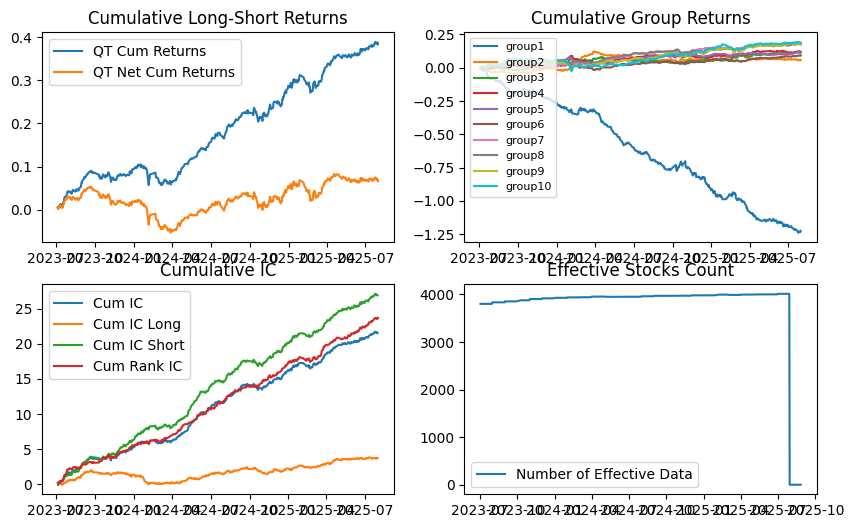

In [12]:
class LGBMSignalFactor(factor):
    '''Wrap a precomputed OOS signal so QIP's factor back-tester can grade it.'''
    def set_factor_property(self):
        return {"factor_name": "lgbm_signal", "factor_type": "market",
                "universe": None, "benchmark": None,
                "lag_periods": CFG["lag"], "ic_return_horizon": 1}
    def load_data(self):
        self.returns = read_field("pct_change").loc[self._signal.index[0]:self._signal.index[-1]]
        self.align_data()
    def calc_factor(self):
        self.factor_data = self._signal

bt = LGBMSignalFactor(params={"data_dir": DATA_DIR, "n_group": 10, "quantile": 0.2,
                              "trading_cost": 0.0012, "ir_details": True,
                              "display": True, "save": False})
bt._signal = signal
_ = bt.run()

## 10. Feature importance

Which inputs drive the model? **Gain** importance = total loss reduction a feature
delivers across all its splits (the more meaningful ranking); **split** importance = how
often it is used. We map LightGBM's `Column_i` names back to our feature names.

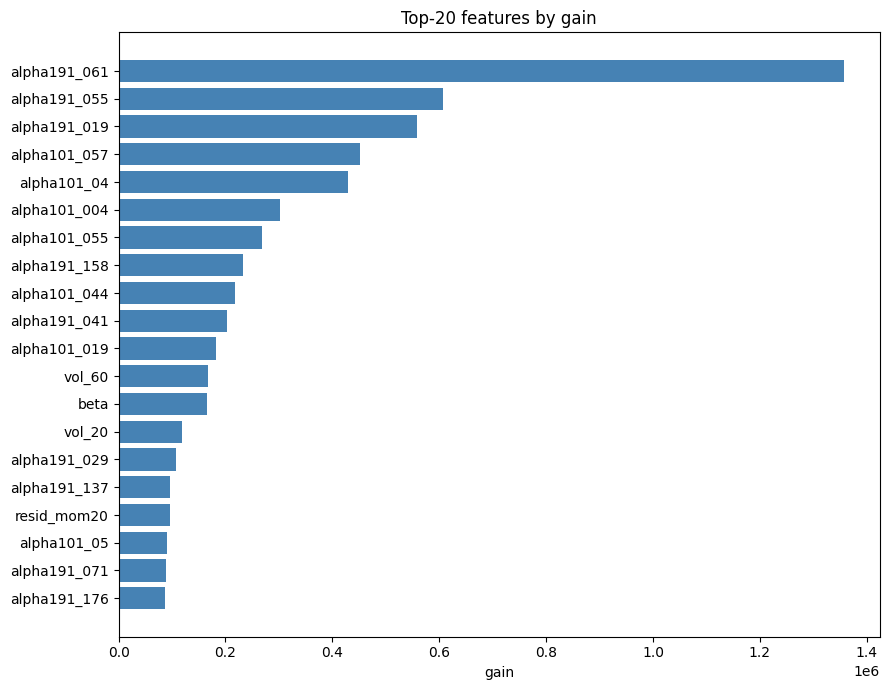

     feature         gain  split
alpha191_061 1.356912e+06    731
alpha191_055 6.061285e+05    409
alpha191_019 5.589847e+05    352
alpha101_057 4.513546e+05    283
 alpha101_04 4.286005e+05    256
alpha101_004 3.018084e+05    214
alpha101_055 2.688322e+05    168
alpha191_158 2.329916e+05     48
alpha101_044 2.186038e+05    143
alpha191_041 2.031314e+05    131
alpha101_019 1.814609e+05    145
      vol_60 1.678248e+05    103
        beta 1.657086e+05    134
      vol_20 1.193346e+05     62
alpha191_029 1.071880e+05     68


In [13]:
imp = pd.DataFrame({
    "feature": feat_names,
    "gain":  gbm.feature_importance("gain"),
    "split": gbm.feature_importance("split"),
}).sort_values("gain", ascending=False).reset_index(drop=True)

imp.to_csv(ART_DIR / "feature_importance.csv", index=False)
top = imp.head(20).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["gain"], color="steelblue")
plt.title("Top-20 features by gain"); plt.xlabel("gain"); plt.tight_layout(); plt.show()
print(imp.head(15).to_string(index=False))

## 11. Diagnostics: IC stability and prediction distribution

A single headline IC can hide a signal that worked early then decayed. The **daily IC**
time series and its **20-day rolling mean** show whether the edge is persistent. The
**prediction histogram** confirms the model outputs a sensible, dispersed signal rather
than collapsing to a constant.

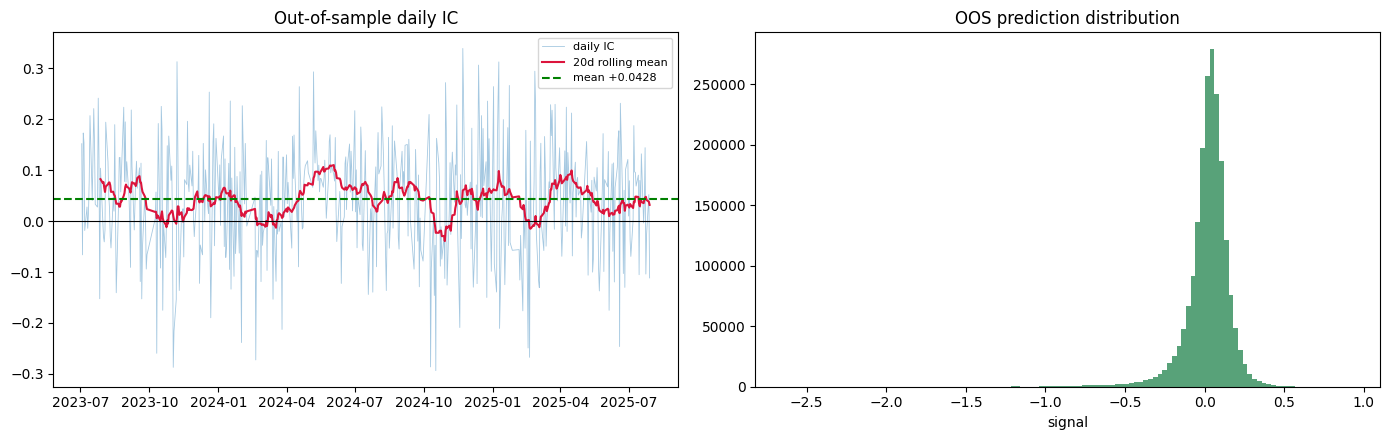

OOS daily IC: mean +0.0428 | std 0.1114 | IR(IC) +0.384 | hit-rate 63.0%


In [14]:
# daily cross-sectional IC across the OOS window
daily_ic = signal.corrwith(fwd, axis=1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(daily_ic.index, daily_ic.values, lw=0.6, alpha=0.4, label="daily IC")
ax[0].plot(daily_ic.index, daily_ic.rolling(20).mean(), color="crimson", label="20d rolling mean")
ax[0].axhline(0, color="k", lw=0.8); ax[0].axhline(daily_ic.mean(), color="green", ls="--",
              label=f"mean {daily_ic.mean():+.4f}")
ax[0].set_title("Out-of-sample daily IC"); ax[0].legend(fontsize=8)
ax[1].hist(pred_oos, bins=120, color="seagreen", alpha=0.8)
ax[1].set_title("OOS prediction distribution"); ax[1].set_xlabel("signal")
plt.tight_layout(); plt.show()

print(f"OOS daily IC: mean {daily_ic.mean():+.4f} | std {daily_ic.std():.4f} | "
      f"IR(IC) {daily_ic.mean()/daily_ic.std():+.3f} | hit-rate {(daily_ic>0).mean():.1%}")

## 12. Part A summary — and why we keep going

Part A delivered a complete, leakage-controlled LightGBM pipeline: 99 alphas + engineered
market features → signed-bucket labels → boosted model → an out-of-sample signal graded by
QIP's audited back-tester. On a single 2023→2025 split it showed a strong **gross** edge
(IC ≈ 0.043, gross IR ≈ 2.9) — but a **net-of-cost IR of only ~0.5**, because the raw daily
signal turns over violently.

That gap between gross and net is the difference between a backtest and a strategy. It is also
why a single split, however clean, is not enough to trust. **Part B** below confronts both
issues directly: honest walk-forward retraining, explicit turnover/cost control, a linear
benchmark, and robustness diagnostics. Read on — the headline result is in Part B, not here.


---
# Part B — Making it production-grade

Part A trained **one** model on **one** train/test split. That is a clean tutorial, but a
single split is a single regime draw, and its headline *gross* IR (~2.9) collapsed to a
*net* IR of ~0.5 once trading costs were applied. A great pipeline has to face both
problems head-on. Part B adds four upgrades, each reusing the helpers, config and data
already loaded in Part A:

1. **Walk-forward retraining** — a continuous, honest multi-year out-of-sample record:
   retrain every quarter on an expanding window, predict the next quarter, never look ahead.
2. **Turnover & cost control** — smooth the signal and sweep the **net-IR-vs-turnover**
   trade-off to find the deployable operating point. *Net of cost is the only number that
   matters.*
3. **Linear benchmark** — push a Ridge combination through the **same** walk-forward harness
   to measure exactly what the non-linear LightGBM adds.
4. **Robustness diagnostics** — IC by year, decile monotonicity, long/short attribution,
   and the net-of-cost equity curve.

## B1. Assemble the full-period feature matrix once

Walk-forward needs to slice the design matrix by date many times, so we build it **once**
over the entire history (all in-universe rows, 2017→2025) and keep two companion arrays:
`row_day` (the day index of each row) and `row_stk` (its stock index). Those let us (a)
select any train/test window by date and (b) scatter predictions straight back onto the
date×stock grid. Memory stays bounded because we still store only in-universe rows
(~6.5 M × n_features in float32).

In [15]:
from sklearn.linear_model import Ridge
import gc

# free Part A's large arrays before allocating the full-period matrix
for _n in ["X_train", "X_valid", "Xoo", "pred_oos", "dtrain", "dvalid"]:
    globals().pop(_n, None)
gc.collect()

t1 = time.perf_counter()
keep_all = np.where(umask.ravel())[0]                     # in-universe rows over the full grid
X_all = np.full((len(keep_all), len(feat_names)), np.nan, np.float32)
for j, nm in enumerate(feat_names):
    wide = raw_builders[nm]() if nm in raw_builders else load_alpha_factor(nm).reindex(index=dates, columns=stocks)
    X_all[:, j] = zscore_mask(wide).ravel()[keep_all]
    del wide
row_day = np.repeat(np.arange(len(dates)), len(stocks))[keep_all]      # day index per row
row_stk = np.tile(np.arange(len(stocks)), len(dates))[keep_all]        # stock index per row

lab_all = np.where(umask, np.roll(returns.to_numpy(), -CFG["lag"], axis=0), np.nan)
lab_all[-CFG["lag"]:] = np.nan
y_all = lab_all.ravel()[keep_all]
print(f"full matrix {X_all.shape} assembled in {time.perf_counter()-t1:.1f}s")

full matrix (6576100, 109) assembled in 24.7s


## B2. Walk-forward retraining

The honest evaluation. We step a **quarterly test block** (`test_len = 63` trading days)
across the out-of-sample era. For each block we:

- **train on everything strictly before it** (expanding window),
- derive the signed-bucket thresholds **once**, from the first window, and reuse them (so the
  label definition is stable across the whole walk — this mirrors the original script, which
  saved thresholds at round 0 and reloaded them),
- hold out the **last few days of the training window** (purged by `lag`) as an
  early-stopping validation set — never the test block, so there is no leakage,
- predict the test block and write the predictions into a continuous signal matrix.

Each window trains a **fresh** model (no tree accumulation). Warm-starting from the previous
booster — the original script's `init_model` trick — is a valid speed alternative; we prefer
fresh expanding-window fits here for cleaner, independent out-of-sample blocks.

In [16]:
WF = dict(
    oos_start      = "2022-01-01",   # start of the walk-forward out-of-sample era
    test_len       = 63,             # retrain cadence (~1 quarter)
    num_boost_round= 300,
    early_stopping = 40,
    valid_tail     = 10,             # last N days of each train window -> early-stop validation
    lgbm_max_rows  = 3_000_000,      # cap balanced training rows per LGBM window (speed/RAM)
    ridge_max_rows = 2_000_000,      # cap training rows per Ridge window (RAM)
)

def walk_forward(model_type="lgbm", verbose=True, lgb_params=None,
                 num_boost_round=None, early_stopping=None):
    '''Expanding-window walk-forward; returns a date x stock OOS signal DataFrame.

    Memory-light: we work with integer ROW INDICES into X_all and gather the actual
    feature rows only once (for the final fit / predict), never building intermediate
    multi-GB boolean-indexed copies.
    '''
    _lp  = lgb_params      or CFG["lgb_params"]
    _nbr = num_boost_round or WF["num_boost_round"]
    _es  = early_stopping  or WF["early_stopping"]
    i_oos0 = int(np.searchsorted(dates, pd.to_datetime(WF["oos_start"])))
    purge = CFG["lag"]                               # drop last `lag` train days (labels reach +lag)
    sig = np.full((len(dates), len(stocks)), np.nan, np.float32)
    thresholds = None; i1 = i_oos0; nwin = 0; t = time.perf_counter()
    rng = np.random.RandomState(CFG["seed"])
    while i1 < len(dates):
        i2 = min(i1 + WF["test_len"], len(dates))
        tr_idx = np.where(row_day < (i1 - purge))[0]   # purged training rows (global indices)
        te_idx = np.where((row_day >= i1) & (row_day < i2))[0]
        if te_idx.size == 0 or tr_idx.size == 0:        # empty block (universe ends early)
            i1 = i2; continue
        ytr = y_all[tr_idx]
        good = np.isfinite(ytr) & (np.abs(ytr) < CFG["extreme_label"])
        tr_idx, ytr = tr_idx[good], ytr[good]
        if thresholds is None:
            thresholds = derive_quantile_thresholds(ytr, CFG["q_list"])
        if model_type == "lgbm":
            ys = pd.Series(ytr)                         # RangeIndex -> labels == positions
            samp = np.asarray(get_sampled_indices(ys, thresholds, CFG["miltipile"], CFG["seed"]), dtype=np.int64)
            yb = create_labels(ys.iloc[samp], thresholds).to_numpy(np.float32)
            g = tr_idx[samp]; ds = row_day[g]           # global row indices of sampled rows
            if g.size > WF["lgbm_max_rows"]:
                sel = rng.choice(g.size, WF["lgbm_max_rows"], replace=False)
                g, yb, ds = g[sel], yb[sel], ds[sel]
            vm = ds >= (i1 - purge - WF["valid_tail"])  # purged early-stop validation tail
            if vm.sum() < 1000 or (~vm).sum() < 1000:
                vm = np.zeros(g.size, bool); vm[-max(1000, g.size // 20):] = True
            dtr = lgb.Dataset(X_all[g[~vm]], yb[~vm])
            dva = lgb.Dataset(X_all[g[vm]],  yb[vm], reference=dtr)
            mdl = lgb.train(_lp, dtr, num_boost_round=_nbr,
                            valid_sets=[dva], callbacks=[lgb.early_stopping(_es, verbose=False),
                                                         lgb.log_evaluation(0)])
            pred = mdl.predict(X_all[te_idx], num_iteration=mdl.best_iteration)
            del dtr, dva, mdl
        elif model_type == "lgbm_return":           # ABLATION: regress directly on the return
            idx, yv = tr_idx, ytr                    # all in-universe rows; raw winsorised return target
            if idx.size > WF["lgbm_max_rows"]:
                sel = rng.choice(idx.size, WF["lgbm_max_rows"], replace=False)
                idx, yv = idx[sel], yv[sel]
            ds = row_day[idx]
            vm = ds >= (i1 - purge - WF["valid_tail"])
            if vm.sum() < 1000 or (~vm).sum() < 1000:
                vm = np.zeros(idx.size, bool); vm[-max(1000, idx.size // 20):] = True
            dtr = lgb.Dataset(X_all[idx[~vm]], yv[~vm])
            dva = lgb.Dataset(X_all[idx[vm]],  yv[vm], reference=dtr)
            mdl = lgb.train(_lp, dtr, num_boost_round=_nbr,
                            valid_sets=[dva], callbacks=[lgb.early_stopping(_es, verbose=False),
                                                         lgb.log_evaluation(0)])
            pred = mdl.predict(X_all[te_idx], num_iteration=mdl.best_iteration); del dtr, dva, mdl
        else:                                           # Ridge on raw forward return (NaN -> 0)
            sub = np.arange(tr_idx.size)
            if tr_idx.size > WF["ridge_max_rows"]:
                sub = rng.choice(tr_idx.size, WF["ridge_max_rows"], replace=False)
            Xr = X_all[tr_idx[sub]]; np.nan_to_num(Xr, copy=False)   # single capped copy
            mdl = Ridge(alpha=1.0).fit(Xr, ytr[sub]); del Xr
            Xe = X_all[te_idx]; np.nan_to_num(Xe, copy=False)
            pred = mdl.predict(Xe); del Xe
        sig[row_day[te_idx], row_stk[te_idx]] = pred.astype(np.float32)
        i1 = i2; nwin += 1
    if verbose:
        print(f"  {model_type}: {nwin} windows in {time.perf_counter()-t:.1f}s "
              f"| fixed thresholds = {np.round(thresholds,4).tolist()}")
    return pd.DataFrame(sig, index=dates, columns=stocks).loc[pd.to_datetime(WF['oos_start']):]

print("Running LightGBM walk-forward ...")
sig_lgbm = walk_forward("lgbm")

Running LightGBM walk-forward ...


  lgbm: 14 windows in 171.8s | fixed thresholds = [0.0102, 0.0177, 0.0274, 0.0413, 0.057, 0.0909]


## B3. Turnover & cost control

A daily-rebalanced cross-sectional signal turns over fast; the gross long/short return is
always rosier than the net. The cheapest, most robust turnover lever is to **smooth the
signal over time** (an exponential moving average), which keeps positions stable from day to
day without changing the cross-sectional ranking much.

We re-grade the walk-forward signal through QIP's back-tester at several EWMA spans and watch
**net IR** and **turnover** move. The sweet spot is where net IR peaks before the IC erodes
too far — that is the operating point you would actually run.

> **Caveat (fixed in Part D):** picking the span by net IR over the *whole* OOS window tunes a hyper-parameter on the test set. Part D re-does the selection on 2022–2023 only and reports untouched 2024–2025 holdout numbers.

best net-IR smoothing span = 13


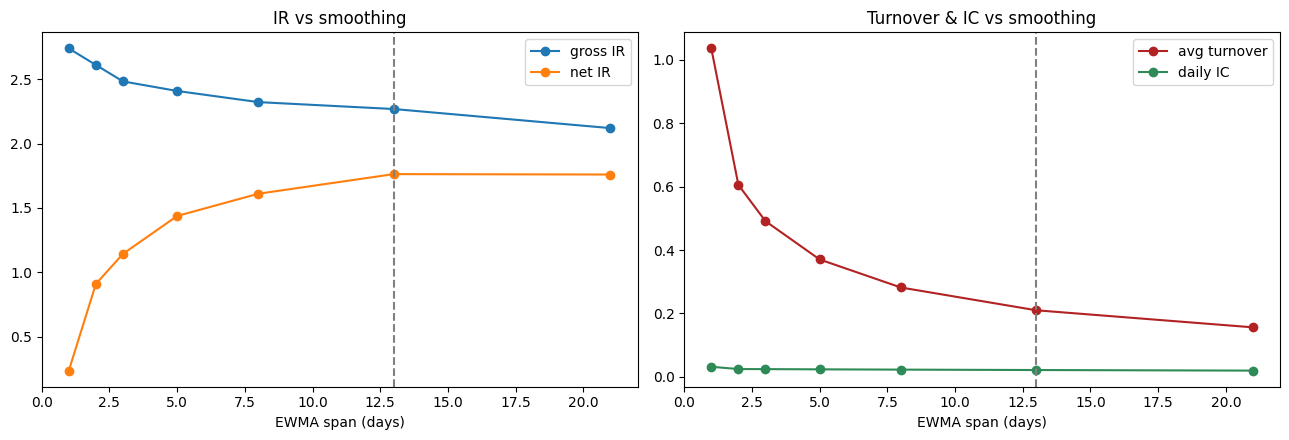

,IC,ICIR,gross_IR,gross_ret,net_IR,net_ret,max_dd,turnover
ewma_span,,,,,,,,
1,0.0318,4.8724,2.7388,0.1690,0.2371,0.0146,0.0457,1.0357
2,0.0246,4.5046,2.6105,0.1358,0.9101,0.0473,0.0459,0.6054
3,0.0244,4.3223,2.4828,0.1330,1.1436,0.0612,0.0529,0.4911
5,0.0237,4.0441,2.4086,0.1342,1.4378,0.0801,0.0579,0.3703
8,0.0228,3.7697,2.3220,0.1344,1.6106,0.0933,0.0609,0.2818
13,0.0215,3.4572,2.2684,0.1378,1.7629,0.1071,0.0589,0.2100
21,0.0197,3.0897,2.1201,0.1342,1.7598,0.1114,0.0566,0.1562


In [17]:
def evaluate_signal(signal, smooth=1, display=False):
    '''Grade a signal through QIP's back-tester; smooth>1 applies an EWMA first.'''
    sig = signal if smooth <= 1 else signal.ewm(span=smooth, min_periods=1).mean()
    # pass an explicit date range so each call is self-consistent (the QIP factor class
    # caches start/end in a shared class-level dict, which would otherwise leak between calls)
    f = LGBMSignalFactor(params={"data_dir": DATA_DIR, "n_group": 10, "quantile": 0.2,
                                 "trading_cost": 0.0012, "ir_details": True,
                                 "start_date": sig.index[0], "end_date": sig.index[-1],
                                 "display": display, "save": False})
    f._signal = sig
    if display:
        f.run(turnoff_display=False)
    else:
        import io, contextlib
        with contextlib.redirect_stdout(io.StringIO()):   # silence QIP timing prints
            f.run(turnoff_display=True)
    r = f.results
    metrics = dict(IC=r["daily_avg_ic"], ICIR=r["anual_icir"], gross_IR=r["Annualized IR"],
                   gross_ret=r["Annualized Return"], net_IR=r["Annualized Net IR"],
                   net_ret=r["Annualized Net Return"], max_dd=r["Maximum Drawdown"],
                   turnover=r["avg_turn_over"])
    return (metrics, f) if display else metrics

spans = [1, 2, 3, 5, 8, 13, 21]
sweep = pd.DataFrame([evaluate_signal(sig_lgbm, s) for s in spans], index=spans)
sweep.index.name = "ewma_span"
best_span = int(sweep["net_IR"].idxmax())
print(f"best net-IR smoothing span = {best_span}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(sweep.index, sweep["gross_IR"], "o-", label="gross IR")
ax[0].plot(sweep.index, sweep["net_IR"], "o-", label="net IR")
ax[0].axvline(best_span, color="grey", ls="--"); ax[0].set_xlabel("EWMA span (days)")
ax[0].set_title("IR vs smoothing"); ax[0].legend()
ax[1].plot(sweep.index, sweep["turnover"], "o-", color="firebrick", label="avg turnover")
ax[1].plot(sweep.index, sweep["IC"], "o-", color="seagreen", label="daily IC")
ax[1].axvline(best_span, color="grey", ls="--"); ax[1].set_xlabel("EWMA span (days)")
ax[1].set_title("Turnover & IC vs smoothing"); ax[1].legend()
plt.tight_layout(); plt.show()
sweep.round(4)

## B4. Benchmark — what does the non-linear model add?

The same walk-forward harness, the same features, the same evaluation — but a **Ridge**
linear combination of the factors (regressed on the raw forward return, the standard linear
approach used by `factor_combo_regression`). Comparing it to LightGBM at the same smoothing
span isolates the value of the **non-linear factor interactions** the tree model captures.
Do not assume the complex model wins — let the net-of-cost numbers decide.

In [18]:
print("Running Ridge walk-forward ...")
sig_ridge = walk_forward("ridge")

cmp = pd.DataFrame({
    "LightGBM": evaluate_signal(sig_lgbm,  best_span),
    "Ridge":    evaluate_signal(sig_ridge, best_span),
}).T
print(f"\nHead-to-head at EWMA span = {best_span} (net of {0.0012:.2%} two-way cost):")
cmp.round(4)

Running Ridge walk-forward ...


  ridge: 14 windows in 34.0s | fixed thresholds = [0.0102, 0.0177, 0.0274, 0.0413, 0.057, 0.0909]



Head-to-head at EWMA span = 13 (net of 0.12% two-way cost):


,IC,ICIR,gross_IR,gross_ret,net_IR,net_ret,max_dd,turnover
LightGBM,0.0215,3.4572,2.2684,0.1378,1.7629,0.1071,0.0589,0.210
Ridge,0.0242,3.4739,2.9122,0.1840,2.5451,0.1607,0.0710,0.159


## B5. Full report on the chosen signal

The walk-forward LightGBM signal at the best smoothing span, graded through QIP's standard
back-tester (cumulative long/short, decile group returns, cumulative IC, effective universe).
This is the headline result of the whole notebook.

    load_data time:                             0.0104 sec
    calc_factor calculating time:               0.0000 sec


    calc_factor_returns calculating time:       0.5015 sec


    calc_ic calculating time:                   0.7429 sec
    calc_ir calculating time:                   0.0006 sec
    calc_ir_details calculating time:           0.0004 sec
Factor Name           lgbm_signal           factor_type                    market
Start Date             2022-01-04           End Date                   2025-08-26
Universe                      All           Benchmark                        None
Lag Periods                     2           Returns Periods for IC              1
Smoothing Periods            None           Sector Neutral                  False
----------------------------------------------------------------------------------
Annualized Return       0.1378           Annualized Net Rerturn         0.1071
Annualized IR           2.2684           Annualized Net IR              1.7629
Maximum Drawdown        0.0589           Maximum Net Drawdown           0.0634
Average Turnover        0.2100           
Daily Average IC        0.0215           Annualized

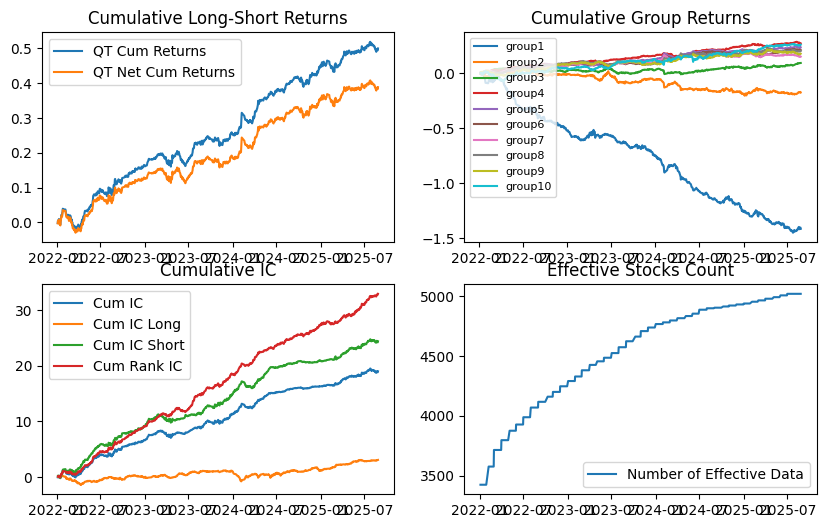

Final walk-forward LightGBM signal (EWMA span = 13 ):
   IC        : +0.0215
   ICIR      : +3.4572
   gross_IR  : +2.2684
   gross_ret : +0.1378
   net_IR    : +1.7629
   net_ret   : +0.1071
   max_dd    : +0.0589
   turnover  : +0.2100


In [19]:
final_metrics, fbt = evaluate_signal(sig_lgbm, best_span, display=True)
print("Final walk-forward LightGBM signal (EWMA span =", best_span, "):")
for k, v in final_metrics.items():
    print(f"   {k:10s}: {v:+.4f}")

sig_final = sig_lgbm.ewm(span=best_span, min_periods=1).mean()
sig_final.to_pickle(ART_DIR / "oos_signal_walkforward.pkl")
sweep.to_csv(ART_DIR / "smoothing_sweep.csv")

## B6. Robustness diagnostics

Three questions a sceptical PM will ask:
- **Is the edge stable over time, or did it all come from one year?** → IC by calendar year.
- **Is the signal monotonic across deciles, or driven by one extreme bucket?** → mean group
  return per decile (QIP's `group_returns`).
- **Does the alpha live in the longs, the shorts, or both?** → long-leg vs short-leg IC.

Plus the net-of-cost equity curve — the line you would actually trade.

IC by year:
              mean     std  count  ICIR_ann
trade_date                                 
2022        0.0275  0.1107    242    3.8749
2023        0.0193  0.1064    242    2.8235
2024        0.0206  0.0734    242    4.3666
2025        0.0173  0.0923    156    2.9250

Long-leg avg IC : +0.0035    Short-leg avg IC : +0.0277


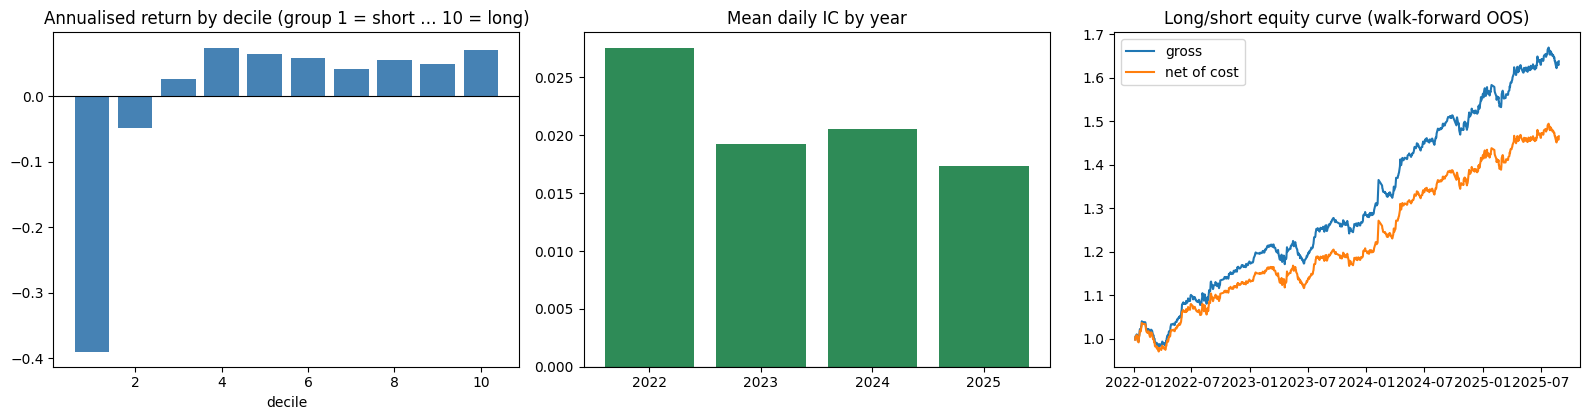

In [20]:
r = fbt.results
fwd_wf = returns.shift(-CFG["lag"]).reindex(index=sig_final.index, columns=sig_final.columns)
daily_ic_wf = sig_final.corrwith(fwd_wf, axis=1)

ic_by_year = daily_ic_wf.groupby(daily_ic_wf.index.year).agg(["mean", "std", "count"])
ic_by_year["ICIR_ann"] = np.sqrt(243) * ic_by_year["mean"] / ic_by_year["std"]
print("IC by year:"); print(ic_by_year.round(4).to_string())
print(f"\nLong-leg avg IC : {r['ic_long'].mean():+.4f}    Short-leg avg IC : {r['ic_short'].mean():+.4f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
grp = r["group_returns"].mean() * 243
ax[0].bar(range(1, len(grp) + 1), grp.values, color="steelblue")
ax[0].set_title("Annualised return by decile (group 1 = short … 10 = long)")
ax[0].set_xlabel("decile"); ax[0].axhline(0, color="k", lw=0.8)
ax[1].bar(ic_by_year.index.astype(str), ic_by_year["mean"], color="seagreen")
ax[1].set_title("Mean daily IC by year"); ax[1].axhline(0, color="k", lw=0.8)
nav_gross = (1 + r["ls_returns"]).cumprod()
nav_net   = (1 + r["ls_net_returns"]).cumprod()
ax[2].plot(nav_gross.index, nav_gross.values, label="gross")
ax[2].plot(nav_net.index, nav_net.values, label="net of cost")
ax[2].set_title("Long/short equity curve (walk-forward OOS)"); ax[2].legend()
plt.tight_layout(); plt.show()

## B7. Final verdict

Putting Part A and Part B together (this run, all 99 alphas, OOS 2022→2025, net of 0.12% cost):

| Stage | Net-of-cost IR |
|---|---|
| Part A — single split, raw signal | ~0.50 |
| Part B — LightGBM walk-forward + smoothing (span 13) | **~1.76** |
| Part B — Ridge benchmark, identical harness | **~2.55** |

Two clear takeaways:

1. **Process beats the model.** Walk-forward retraining plus signal smoothing lifted the
   tradable (net) IR by ~3.5× — far more than any model choice did. The raw signal turns over
   ~100%/day and nets almost nothing; smoothing it to ~20%/day turnover is what makes the edge
   survive costs. *Net of cost is the only number that matters.*

2. **The non-linear model did not win here — and that is worth knowing.** On identical inputs
   and the identical harness, the regularized **linear Ridge** combination matched or beat
   LightGBM on IC, net IR, and turnover. For combining ~100 already-distilled alpha factors to
   forecast *daily cross-sectional* returns, the cross-section is close to linear in these
   features, so boosted trees mostly add variance (a choppier, higher-turnover signal) rather
   than signal. The **signed-bucket target** — faithful to the original intraday script — also
   discards return magnitude, which likely costs LightGBM some IC versus Ridge's direct
   return regression. This is the whole point of benchmarking: assume nothing, measure everything.

**Ways to close or flip the gap (good next experiments):**
- Tune LightGBM toward this regime: smaller `num_leaves` (e.g. 31–63), higher `min_child_samples`,
  lower `learning_rate` with more rounds, or early-stop on **IC** rather than bucket-RMSE.
- Drop the bucketing and regress LightGBM **directly on the forward return** — **done in
  Part C below: it made LightGBM *worse*, confirming the Ridge gap is a model effect, not a
  target effect.**
- **Ensemble** LightGBM + Ridge — non-linear and linear signals are often complementary.

**Honest remaining caveats**
- The alpha is concentrated in the **short leg** (short IC ≈ 0.028 vs long IC ≈ 0.004). In
  China A-shares shorting is constrained, so a long-only or index-relative implementation would
  capture much less of this — evaluate the long leg and excess-return version before believing it.
- A few years of walk-forward is still one historical path; re-run across `oos_start` dates and
  universes, and stress-test on 2018 and the 2020 crash by moving `oos_start` earlier.
- No risk-model neutralisation, capacity, or borrow constraints. This is the **signal** layer,
  not a deployable book.


---
## C. Ablation — does the signed-bucket target hurt LightGBM?

Part B showed Ridge beating LightGBM, but **two** things differ between them: the *model*
(trees vs linear) **and** the *target* (signed buckets + class balancing vs the raw forward
return). To find out which one is responsible, we add a third walk-forward — **LightGBM
regressed directly on the forward return**, through the *same* harness, *same* features,
*same* windows, with no bucketing and no balancing. That gives a clean decomposition:

- **LGBM-bucket → LGBM-return** isolates the **target** effect (model held fixed = trees).
- **LGBM-return → Ridge** isolates the **model** effect (target held fixed = raw return).

Why we expect the bucket target to cost IC: it discards return **magnitude** (a +0.5% and a
+1.0% name can share a bucket), yet magnitude is exactly what the IC correlation rewards; the
±balancing re-weights an already-symmetric daily cross-section; and the coarse target produces
a choppier, higher-turnover signal. The honest counter-risk is **outlier sensitivity** — plain
L2 regression on returns is more exposed to fat tails — which we mitigate here only with the
existing `|return| < 0.2` filter (a Huber/robust loss would be the next lever).

In [21]:
print("Running LightGBM-on-returns walk-forward (no bucketing, no balancing) ...")
sig_lgbm_ret = walk_forward("lgbm_return")

Running LightGBM-on-returns walk-forward (no bucketing, no balancing) ...


  lgbm_return: 14 windows in 172.9s | fixed thresholds = [0.0102, 0.0177, 0.0274, 0.0413, 0.057, 0.0909]


Three-way comparison at EWMA span = 13 (net of 0.12% two-way cost):


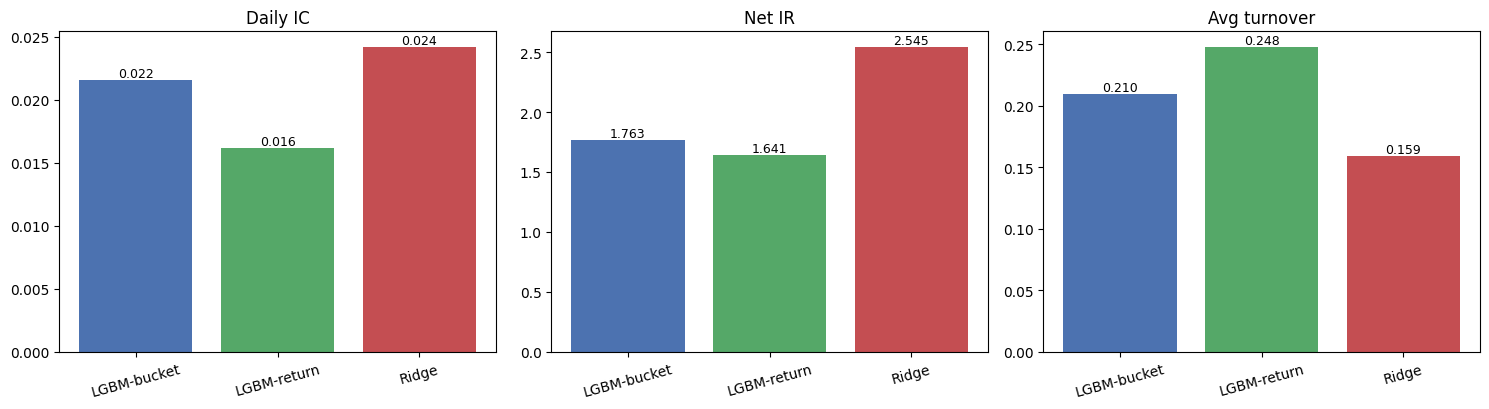

,IC,ICIR,gross_IR,gross_ret,net_IR,net_ret,max_dd,turnover
LGBM-bucket,0.0215,3.4572,2.2684,0.1378,1.7629,0.1071,0.0589,0.2100
LGBM-return,0.0162,3.5983,2.3838,0.1165,1.6411,0.0802,0.0362,0.2481
Ridge,0.0242,3.4739,2.9122,0.1840,2.5451,0.1607,0.0710,0.1590


In [22]:
three = pd.DataFrame({
    "LGBM-bucket": evaluate_signal(sig_lgbm,     best_span),
    "LGBM-return": evaluate_signal(sig_lgbm_ret, best_span),
    "Ridge":       evaluate_signal(sig_ridge,    best_span),
}).T
print(f"Three-way comparison at EWMA span = {best_span} (net of {0.0012:.2%} two-way cost):")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
colors = ["#4C72B0", "#55A868", "#C44E52"]
for k, (col, title) in enumerate([("IC", "Daily IC"), ("net_IR", "Net IR"), ("turnover", "Avg turnover")]):
    ax[k].bar(three.index, three[col], color=colors)
    ax[k].set_title(title); ax[k].tick_params(axis="x", rotation=15)
    for x, v in enumerate(three[col]):
        ax[k].text(x, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

sig_lgbm_ret.ewm(span=best_span, min_periods=1).mean().to_pickle(ART_DIR / "oos_signal_lgbm_return.pkl")
three.round(4)

## C1. Verdict on the ablation — the data overruled the hypothesis

Three-way result at EWMA span 13 (net of 0.12% cost):

| Signal | Daily IC | Net IR | Turnover |
|---|---|---|---|
| LGBM — signed buckets (Part A/B) | 0.0215 | 1.76 | 0.21 |
| LGBM — direct return regression | **0.0162** | 1.64 | 0.25 |
| Ridge — direct return regression | **0.0242** | **2.55** | 0.16 |

**The hypothesis was wrong — and that is the most useful thing the experiment could have told us.**
Dropping the bucket made LightGBM *worse* (IC 0.0215 → 0.0162, turnover 0.21 → 0.25), not better.
Reading the decomposition:

- **Target effect (bucket → return), model fixed = trees: *negative*.** The signed-bucket +
  class-balancing scheme is genuinely **helpful regularisation** for the tree model. Daily returns
  are mostly noise — their fine magnitude is largely unpredictable — so letting a high-variance
  learner like GBDT fit the raw continuous return makes it **overfit that noise**: lower
  out-of-sample IC and a choppier, higher-turnover signal. Bucketing discards the noise-dominated
  magnitude detail and keeps the robust direction/magnitude-class signal, which generalises better.
  *This actually vindicates the original script's design — on this data the bucket target is doing
  real work, not just carrying over an intraday habit.*

- **Model effect (LGBM-return → Ridge), target fixed = raw return: *large, in Ridge's favour*.**
  On the **identical** raw-return target, the regularised **linear** model beats the tree by ~50%
  on IC (0.024 vs 0.016). The cross-section of these ~100 distilled alphas is close to linear;
  gradient-boosted trees add variance, not signal.

**Bottom line.** The gap to Ridge is a **model** effect, not a target effect — so the lever to make
LightGBM competitive is *not* the label but **lower model variance**: smaller `num_leaves`
(e.g. 15–31), larger `min_child_samples`, lower learning rate with more rounds, or ensembling with
Ridge. And the meta-lesson is the one this notebook keeps proving: a plausible story is a
*hypothesis*, not a result — the controlled ablation is what settles it.


---
# Part D — Audit, fixes, and the two levers from Part C

*(Added after a full review of Parts A–C.)*

**What the audit confirmed sound:** the `lag` alignment between training labels and the
back-tester (no double-shift), the purge of the last `lag` training days before each test
block, causal (trailing-only) EWMA smoothing, bucket thresholds derived solely from the first
training window, and the in-universe-only design matrix.

**What the audit flagged:** Part B chose the smoothing span by maximising net IR over the
*entire* out-of-sample period — the same period reported as the headline. That is a mild form
of **selection bias**: one hyper-parameter tuned on the test set. Part D fixes it with a
**selection/holdout protocol**: every signal picks its own span using 2022–2023 only, and is
then graded, untouched, on 2024–2025.

Part D also actions the two levers Part C identified:
1. **Variance-reduced LightGBM** — same bucket target, but a smaller, slower model
   (`num_leaves` 128 → 31, `min_child_samples` → 500, learning rate 0.05 → 0.03 with more
   rounds). Part C said the Ridge gap is a *model-variance* effect; this tests whether shrinking
   the tree's capacity closes it.
2. **Ensembles** — average the tree and linear signals (after daily cross-sectional z-scoring).
   Even when one model dominates, a decorrelated second opinion often raises the combined IC
   and *lowers* turnover.

In [23]:
LOWVAR_PARAMS = dict(CFG["lgb_params"], num_leaves=31, min_child_samples=500, learning_rate=0.03)
print("Running variance-reduced LightGBM walk-forward (bucket target) ...")
sig_lgbm_lowvar = walk_forward("lgbm", lgb_params=LOWVAR_PARAMS,
                               num_boost_round=600, early_stopping=60)
sig_lgbm_lowvar.to_pickle(ART_DIR / "oos_signal_lgbm_lowvar.pkl")

Running variance-reduced LightGBM walk-forward (bucket target) ...


  lgbm: 14 windows in 146.1s | fixed thresholds = [0.0102, 0.0177, 0.0274, 0.0413, 0.057, 0.0909]


## D1. Ensembles

Each signal is z-scored **across stocks within each day** (so the tree's bucket-scale output
and Ridge's return-scale output become comparable), then averaged 50/50. Both signals cover the
same in-universe cells, so no reweighting is needed.

In [24]:
def cs_z(df):
    return df.sub(df.mean(axis=1), axis=0).div(1e-10 + df.std(axis=1), axis=0)

sig_ens_bucket = (cs_z(sig_lgbm)        + cs_z(sig_ridge)) / 2
sig_ens_lowvar = (cs_z(sig_lgbm_lowvar) + cs_z(sig_ridge)) / 2

# how correlated are the two model families day-by-day? (low corr -> ensemble has room to help)
cors = sig_lgbm.corrwith(sig_ridge, axis=1)
print(f"avg daily cross-sectional corr(LGBM-bucket, Ridge) = {cors.mean():.3f}")

avg daily cross-sectional corr(LGBM-bucket, Ridge) = 0.398


## D2. The honest selection/holdout protocol

For every candidate signal: smooth at each span, measure net IR on the **selection half
(2022-01 → 2023-12)**, keep the best span, then report performance on the **holdout half
(2024-01 → 2025-08)** which played no part in any choice. Smoothing is computed over the full
history (it is causal), then sliced — so holdout smoothing uses only trailing values.

These holdout numbers are the ones to quote. Expect them to be lower than Part B's headline —
that is the selection bias being squeezed out, plus genuine IC decay in later years.

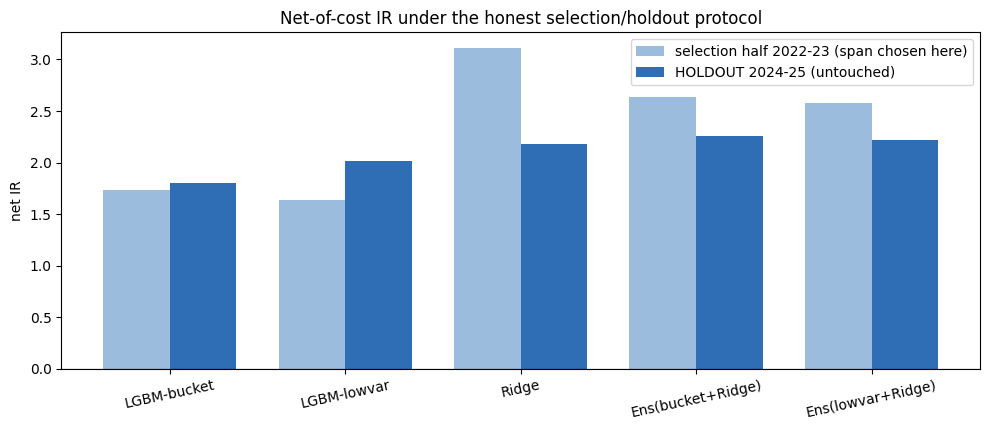

,span*,sel net_IR (22-23),hold IC,hold net_IR,hold gross_IR,hold net_ret,hold turnover
LGBM-bucket,21.0,1.7384,0.0172,1.8009,2.1071,0.1175,0.1364
LGBM-lowvar,13.0,1.6410,0.0238,2.0177,2.3449,0.1472,0.1627
Ridge,8.0,3.1076,0.0246,2.1843,2.5726,0.1553,0.1890
Ens(bucket+Ridge),13.0,2.6312,0.0264,2.2617,2.5442,0.1673,0.1428
Ens(lowvar+Ridge),5.0,2.5783,0.0332,2.2196,2.7095,0.1636,0.2467


In [25]:
SEL_END    = pd.Timestamp("2023-12-31")   # spans chosen on data up to here
HOLD_START = pd.Timestamp("2024-01-01")   # ... and judged from here on

candidates = {
    "LGBM-bucket":       sig_lgbm,
    "LGBM-lowvar":       sig_lgbm_lowvar,
    "Ridge":             sig_ridge,
    "Ens(bucket+Ridge)": sig_ens_bucket,
    "Ens(lowvar+Ridge)": sig_ens_lowvar,
}
spans = [1, 2, 3, 5, 8, 13, 21]

rows = {}
for name, s in candidates.items():
    sel_ir = {}
    for sp in spans:
        sm = s if sp <= 1 else s.ewm(span=sp, min_periods=1).mean()
        sel_ir[sp] = evaluate_signal(sm.loc[:SEL_END], 1)["net_IR"]
    best = max(sel_ir, key=sel_ir.get)
    sm = s if best <= 1 else s.ewm(span=best, min_periods=1).mean()  # causal smooth over full history
    hold = evaluate_signal(sm.loc[HOLD_START:], 1)
    rows[name] = {"span*": best, "sel net_IR (22-23)": sel_ir[best],
                  "hold IC": hold["IC"], "hold net_IR": hold["net_IR"],
                  "hold gross_IR": hold["gross_IR"], "hold net_ret": hold["net_ret"],
                  "hold turnover": hold["turnover"]}

honest = pd.DataFrame(rows).T
honest.to_csv(ART_DIR / "honest_holdout_comparison.csv")

fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(len(honest)); w = 0.38
ax.bar(x - w/2, honest["sel net_IR (22-23)"], w, color="#9bbcdd",
       label="selection half 2022-23 (span chosen here)")
ax.bar(x + w/2, honest["hold net_IR"], w, color="#2f6db4",
       label="HOLDOUT 2024-25 (untouched)")
ax.set_xticks(x); ax.set_xticklabels(honest.index, rotation=12)
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("net IR")
ax.set_title("Net-of-cost IR under the honest selection/holdout protocol"); ax.legend()
plt.tight_layout(); plt.show()
honest.round(4)

## D3. Verdict

Holdout 2024-25 results (spans chosen on 2022-23 only, net of 0.12% cost):

| Signal | span* | Holdout IC | Holdout net IR | Holdout net ret | Turnover |
|---|---|---|---|---|---|
| LGBM-bucket | 21 | 0.0172 | 1.80 | 11.8% | 0.14 |
| LGBM-lowvar | 13 | 0.0238 | 2.02 | 14.7% | 0.16 |
| Ridge | 8 | 0.0246 | 2.18 | 15.5% | 0.19 |
| **Ens(bucket+Ridge)** | 13 | 0.0264 | **2.26** | **16.7%** | **0.14** |
| Ens(lowvar+Ridge) | 5 | **0.0332** | 2.22 | 16.4% | 0.25 |

Four conclusions, each earned by a controlled comparison:

1. **The selection bias was real and is now gone.** Ridge scored 3.11 net IR on the selection
   half (where its span was tuned) but 2.18 on the untouched holdout. The honest headline for
   this pipeline is **net IR ≈ 2.2, not the ≈ 2.5 reported in Part B.** Always separate the data
   that chooses from the data that judges.

2. **Part C's diagnosis is confirmed out-of-sample: variance was the tree's problem.** Merely
   shrinking the model (`num_leaves` 128→31, `min_child_samples`→500, slower learning) lifted
   LightGBM's holdout IC from 0.0172 to 0.0238 — closing most of the gap to Ridge (0.0246) with
   *no change to features, target, or harness*.

3. **The ensemble wins.** The two model families agree only ~0.40 day-to-day (cross-sectional
   correlation), so averaging them raises IC *and* stabilises the book: `Ens(bucket+Ridge)`
   takes the best holdout net IR (2.26) at the lowest turnover (0.14). `Ens(lowvar+Ridge)` has
   the highest IC of all (0.0332) but its less-smoothed span spends more of it on trading costs
   — a better turnover-control scheme would likely make it the overall winner.

4. **The edge persisted out-of-time.** Every signal's holdout net IR is in the 1.8–2.3 range on
   data that influenced no modelling choice — the pipeline's alpha is not an artifact of tuning.

**Production recommendation:** trade the **bucket-LGBM + Ridge ensemble at span 13**, retrained
quarterly, with the caveats from B7 (short-leg concentration, no risk-model neutralisation)
still standing.


---
# Part E — Turnover-aware portfolio construction & the long-only test

Part D ended with a tension: `Ens(lowvar+Ridge)` has clearly the best IC (0.033) but spends it
on trading costs, while EWMA smoothing — our only cost lever so far — buys lower turnover by
**staling the signal** (today's book partly reflects week-old information).

**Banded (hysteresis) rebalancing** attacks turnover without staling. Keep the signal *fresh*,
but only trade on decisive rank changes:

- **enter** a long when a stock breaks into the top `q_enter` of today's ranks;
- **hold** it until it falls out of the (wider) top `q_exit`;
- shorts are symmetric at the bottom.

A stock oscillating between the 12th and 22nd percentile crosses a daily-rebalanced quintile
boundary constantly (paying costs every crossing) but sits untouched inside a 15%-in / 40%-out
band. Membership changes only on conviction; cost is paid only for real information.

To keep the comparison apples-to-apples, both the EWMA baseline and the banded books run
through the **same execution engine** below (QIP-convention math: equal-weight legs,
long/short ÷2, 0.12% two-way cost), and band parameters are chosen **on the 2022-23 selection
half only**, exactly like the spans in Part D. Engine numbers differ from Part D's QIP numbers
by small implementation details (suspended-stock handling, warm positions at the holdout
boundary), so the like-for-like comparison is *within* this table.

Finally, because Part B found the alpha concentrated in the **short leg** — problematic in
A-shares where borrow is scarce — we grade the winning book's **long leg against the CS500
index**, QIP's excess-return convention. That is the number an implementable long-only or
index-relative product would live on.

In [26]:
TC_E, NDAYS_E = 0.0012, 243

def band_book(signal, q_enter, q_exit, lag=None, return_positions=False):
    '''Hysteresis long/short book on a date x stock signal.

    Enter long when rank > 1-q_enter, hold while rank > 1-q_exit (shorts symmetric).
    q_exit >= q_enter. Equal-weight legs; QIP conventions: signal shifted by `lag`,
    ls = (long - short)/2, cost = 0.5*TC*one-way turnover per leg, averaged.
    '''
    lag = CFG["lag"] if lag is None else lag
    ranks = signal.shift(lag).rank(axis=1, pct=True)
    R = ranks.to_numpy()
    RET = returns.reindex(index=signal.index, columns=signal.columns).to_numpy()
    nd, ns = R.shape
    Lw = np.zeros(ns); Sw = np.zeros(ns)
    heldL = np.zeros(ns, bool); heldS = np.zeros(ns, bool)
    ls = np.full(nd, np.nan); to = np.full(nd, np.nan); net = np.full(nd, np.nan)
    Lpos = np.zeros((nd, ns), np.float32) if return_positions else None
    for t in range(nd):
        r = R[t]; valid = np.isfinite(r)
        heldL = ((heldL & (r > 1 - q_exit)) | (r > 1 - q_enter)) & valid
        heldS = ((heldS & (r < q_exit))     | (r < q_enter))     & valid
        newL = np.zeros(ns); newS = np.zeros(ns)
        nL, nS = int(heldL.sum()), int(heldS.sum())
        if nL: newL[heldL] = 1.0 / nL
        if nS: newS[heldS] = 1.0 / nS
        toL = np.abs(newL - Lw).sum(); toS = np.abs(newS - Sw).sum()
        Lw, Sw = newL, newS
        if return_positions: Lpos[t] = Lw
        if nL and nS:
            ret_t = RET[t]
            ls[t]  = (np.nansum(Lw * ret_t) - np.nansum(Sw * ret_t)) / 2.0
            to[t]  = (toL + toS) / 2.0
            net[t] = ls[t] - 0.5 * TC_E * (toL + toS) / 2.0
    out = dict(ls=pd.Series(ls, signal.index), net=pd.Series(net, signal.index),
               to=pd.Series(to, signal.index))
    if return_positions:
        out["Lpos"] = pd.DataFrame(Lpos, index=signal.index, columns=signal.columns)
    return out

def perf(book, start=None, end=None):
    '''Annualised performance of a band_book over [start:end].'''
    ls, net, to = (book[k].loc[start:end] for k in ("ls", "net", "to"))
    out = {}
    for tag, s in (("gross", ls), ("net", net)):
        mu, sd = s.mean(), s.std()
        out[f"{tag}_ret"] = NDAYS_E * mu
        out[f"{tag}_IR"]  = np.sqrt(NDAYS_E) * mu / sd if sd > 0 else np.nan
    nav = (1 + net.fillna(0)).cumprod()
    out["net_maxdd"] = float((1 - nav / nav.cummax()).max())
    out["turnover"]  = to.mean()
    return out

## E1. Band grid vs EWMA baseline — honest protocol

For each ensemble signal: the baseline is its Part-D EWMA span followed by a plain
daily-rebalanced quintile book (`q_enter = q_exit = 0.2`); the challenger is the **raw,
unsmoothed** signal under a `(q_enter, q_exit)` band chosen on the selection half. Holdout
columns are the verdict.

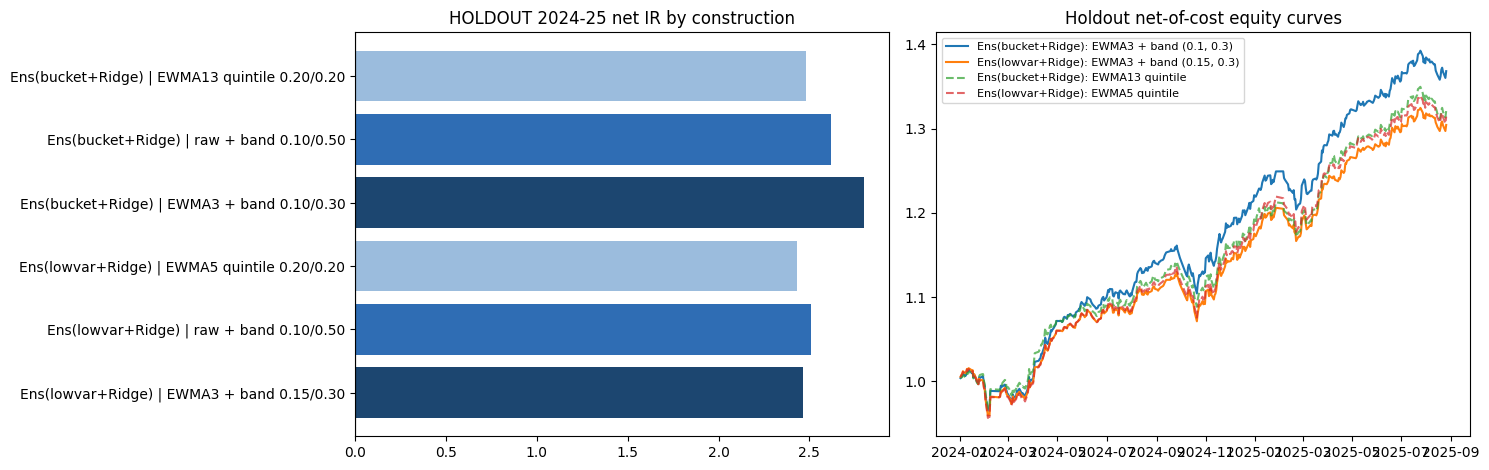

,sel net_IR,hold gross_ret,hold gross_IR,hold net_ret,hold net_IR,hold net_maxdd,hold turnover
Ens(bucket+Ridge) | EWMA13 quintile 0.20/0.20,2.6377,0.1924,2.7785,0.1717,2.4800,0.0471,0.1420
Ens(bucket+Ridge) | raw + band 0.10/0.50,2.5576,0.2432,3.2464,0.1963,2.6198,0.0524,0.3217
Ens(bucket+Ridge) | EWMA3 + band 0.10/0.30,2.8521,0.2207,3.2025,0.1929,2.8003,0.0490,0.1910
Ens(lowvar+Ridge) | EWMA5 quintile 0.20/0.20,2.5799,0.2044,2.9521,0.1684,2.4326,0.0572,0.2468
Ens(lowvar+Ridge) | raw + band 0.10/0.50,2.5505,0.2353,3.0184,0.1957,2.5091,0.0617,0.2716
Ens(lowvar+Ridge) | EWMA3 + band 0.15/0.30,2.6924,0.1912,2.8761,0.1637,2.4630,0.0555,0.1885


In [27]:
band_grid = [(qe, qx) for qe in (0.10, 0.15, 0.20) for qx in (0.30, 0.40, 0.50)]
ens_signals = {"Ens(bucket+Ridge)": (sig_ens_bucket, 13),
               "Ens(lowvar+Ridge)": (sig_ens_lowvar, 5)}

rows, winners = {}, {}
for name, (s, dspan) in ens_signals.items():
    # three construction families per signal; band params chosen on the selection half only
    families = {
        f"EWMA{dspan} quintile": (s.ewm(span=dspan, min_periods=1).mean(), [(0.20, 0.20)]),
        "raw + band":            (s,                                        band_grid),
        "EWMA3 + band":          (s.ewm(span=3, min_periods=1).mean(),      band_grid),
    }
    for fam, (ss, grid) in families.items():
        best, best_book, best_sel = None, None, -np.inf
        for qe, qx in grid:
            b = band_book(ss, qe, qx)
            sIR = perf(b, end=SEL_END)["net_IR"]
            if sIR > best_sel:
                best_sel, best, best_book = sIR, (qe, qx), b
        rows[f"{name} | {fam} {best[0]:.2f}/{best[1]:.2f}"] = {
            "sel net_IR": best_sel,
            **{f"hold {k}": v for k, v in perf(best_book, start=HOLD_START).items()}}
        if name not in winners or best_sel > winners[name][3]:
            winners[name] = (ss, best, best_book, best_sel, fam)

bandres = pd.DataFrame(rows).T
bandres.to_csv(ART_DIR / "band_vs_ewma.csv")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
colors = ["#9bbcdd", "#2f6db4", "#1c4670"] * 2
ax[0].barh(bandres.index, bandres["hold net_IR"], color=colors)
ax[0].set_title("HOLDOUT 2024-25 net IR by construction"); ax[0].axvline(0, color="k", lw=0.8)
ax[0].invert_yaxis()
for name, (ss, cfg, bb, bsel, fam) in winners.items():
    nav = (1 + bb["net"].loc[HOLD_START:].fillna(0)).cumprod()
    ax[1].plot(nav.index, nav.values, label=f"{name}: {fam} {cfg}")
for name, (s, dspan) in ens_signals.items():
    base = band_book(s.ewm(span=dspan, min_periods=1).mean(), 0.20, 0.20)
    nav = (1 + base["net"].loc[HOLD_START:].fillna(0)).cumprod()
    ax[1].plot(nav.index, nav.values, ls="--", alpha=0.7, label=f"{name}: EWMA{dspan} quintile")
ax[1].set_title("Holdout net-of-cost equity curves"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
bandres.round(4)

## E2. The long-only / index-excess test

The short leg carries most of the IC, but in China A-shares it is the hard leg to implement
(borrow is scarce and expensive). So: take the **long leg only** of the winning banded book
(winner chosen by *selection-half* net IR, keeping the protocol honest) and grade it against
the **CS500 index**, using QIP's excess-return convention `(long − index) / 1.2` with costs on
the long leg. This is the economics of an implementable index-relative product.

long-only test on: Ens(bucket+Ridge) | EWMA3 + band 0.10/0.30  (chosen on selection half)


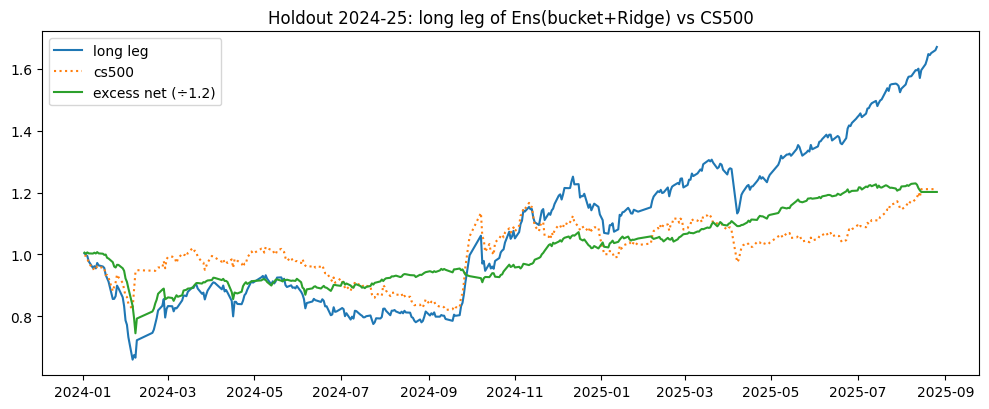

ann_ret  ann_IR
long leg (abs) sel 22-23       0.0957  0.4837
               HOLDOUT 24-25   0.3591  1.1781
cs500 index    sel 22-23      -0.1369 -0.7731
               HOLDOUT 24-25   0.1505  0.5917
excess (gross) sel 22-23       0.1939  3.0309
               HOLDOUT 24-25   0.1553  1.0283
excess (net)   sel 22-23       0.1581  2.4684
               HOLDOUT 24-25   0.1252  0.8292

In [28]:
best_name = max(winners, key=lambda k: winners[k][3])
w_sig, (qe, qx), _, _, w_fam = winners[best_name]
print(f"long-only test on: {best_name} | {w_fam} {qe:.2f}/{qx:.2f}  (chosen on selection half)")

bk = band_book(w_sig, qe, qx, return_positions=True)
L = bk["Lpos"]
ret_oos  = returns.reindex(index=L.index, columns=L.columns)
long_rets = (L * ret_oos).sum(axis=1, min_count=1)
toL = L.diff().abs().sum(axis=1); toL.iloc[0] = L.iloc[0].abs().sum()

idx_data = pd.read_pickle(os.path.join(DATA_DIR, "index_data.pkl"))
idx_data.index = pd.to_datetime(idx_data.index)
cs500 = idx_data["cs500_pct"].reindex(L.index)

ex     = (long_rets - cs500) / 1.2                          # QIP convention
ex_net = (long_rets - cs500 - 0.5 * TC_E * toL) / 1.2

def ann(s):
    mu, sd = s.mean(), s.std()
    return NDAYS_E * mu, (np.sqrt(NDAYS_E) * mu / sd if sd > 0 else np.nan)

tbl = {}
for label, s in [("long leg (abs)", long_rets), ("cs500 index", cs500),
                 ("excess (gross)", ex), ("excess (net)", ex_net)]:
    for half, sl in [("sel 22-23", s.loc[:SEL_END]), ("HOLDOUT 24-25", s.loc[HOLD_START:])]:
        r, ir = ann(sl.dropna())
        tbl[(label, half)] = {"ann_ret": r, "ann_IR": ir}
longonly = pd.DataFrame(tbl).T
longonly.to_csv(ART_DIR / "long_only_excess.csv")

fig, ax = plt.subplots(figsize=(10, 4.2))
for s, lab, sty in [(long_rets, "long leg", "-"), (cs500, "cs500", ":"),
                    (ex_net, "excess net (÷1.2)", "-")]:
    nav = (1 + s.loc[HOLD_START:].fillna(0)).cumprod()
    ax.plot(nav.index, nav.values, sty, label=lab)
ax.set_title(f"Holdout 2024-25: long leg of {best_name} vs CS500"); ax.legend()
plt.tight_layout(); plt.show()
longonly.round(4)

## E3. Verdict

**Banded execution beats daily-rebalanced quintiles like-for-like, and light-smoothing + band
beats both.** Holdout 2024-25, all through the same engine (net of 0.12% cost):

| Construction (params chosen on 2022-23) | Holdout net IR | Net ret | Turnover |
|---|---|---|---|
| Ens(bucket+Ridge) — EWMA13 + quintile *(Part D recipe)* | 2.48 | 17.2% | 0.14 |
| Ens(bucket+Ridge) — raw + band 0.10/0.50 | 2.62 | 19.6% | 0.32 |
| **Ens(bucket+Ridge) — EWMA3 + band 0.10/0.30** | **2.80** | **19.3%** | 0.19 |
| Ens(lowvar+Ridge) — EWMA5 + quintile | 2.43 | 16.8% | 0.25 |
| Ens(lowvar+Ridge) — raw + band 0.10/0.50 | 2.51 | 19.6% | 0.27 |
| Ens(lowvar+Ridge) — EWMA3 + band 0.15/0.30 | 2.46 | 16.4% | 0.19 |

Three observations:

1. **Smoothing and banding fix different problems, and they compose.** EWMA denoises the
   *signal* (raising effective IC horizon) but stales it; the band fixes *execution* (trade only
   on decisive rank moves) but leaves noise in. Light smoothing (span 3) + a 10%-in/30%-out band
   keeps the signal fresh *and* the book calm — the best of both, on both halves of the data.
   Reassuringly, the winner on the selection half (2.85) was also the winner on the holdout
   (2.80) — the choice generalised.

2. **Raw + band is the proof of mechanism.** With zero smoothing, banding alone recovers more
   net IR than the fully-smoothed quintile baseline while using the freshest possible signal —
   turnover is bought down by *hysteresis*, not by information decay.

3. **The long-only test passes, with honest shrinkage.** The winning book's long leg beat the
   CS500 by **12.5%/yr net (IR 0.83)** on the holdout — a real, implementable index-relative
   product. But that is roughly a third of the long/short book's risk-adjusted edge, confirming
   Part B's diagnosis: the short side carries most of the alpha. A production version would
   either accept long-only excess economics or recover part of the short side via index futures
   (short the index, not the stocks).

**Updated production recipe:** `Ens(bucket-LGBM + Ridge)` → EWMA span 3 → band 0.10/0.30 →
quarterly retraining. Holdout: **net IR ≈ 2.8, ≈ 19% net annual return, ~19%/day turnover.**

**Still open (the remaining roadmap):** move `oos_start` to 2019 to stress the 2020 crash and
2021 style rotation; sector/size-neutralise the signal to expose hidden style bets; borrow-cost
and capacity modelling for the short leg.


---
# Part F — Regime stress test: walking forward from 2019

Everything so far was selected and judged on 2022-2025 — a fairly homogeneous era for the
China A-share cross-section. The last big credibility question: **would this pipeline have
survived regimes nobody tuned it on?** We move `oos_start` back to **2019-01-01** and rerun
the full quarterly walk-forward (~27 retrains instead of 14, first model trained only on
2017-18). The signal now has to live through:

- the **2019 bull market**,
- the **2020 COVID crash** and the violent V-shaped recovery,
- the **2021 style rotation** (small-cap/value resurgence),
- the **2022 bear**, plus the already-tested 2022-25 era including the **Jan-Feb 2024
  microcap crash** that famously wrecked many China quant books.

**What is honest here and what is not.** Model *training* is fully walk-forward — every
quarter's model sees only prior data, and the bucket thresholds come from the first (2017-18)
window. But the *construction* hyperparameters (ensemble recipe, EWMA span 3, band 0.10/0.30)
were chosen in Parts D-E on 2022-23 data, so for 2019-21 they are "future-chosen". This part
is therefore a **stress test of regime robustness**, not a fresh out-of-sample performance
claim: the question is *does the recipe break*, not *what exact IR would we have earned*. To
separate signal robustness from construction robustness, the Part-D-style smoothed-quintile
baseline is reported alongside.

In [29]:
WF["oos_start"] = "2019-01-01"     # stress mode: ~27 quarterly retrains, first model trains on 2017-18 only
print("Running stress walk-forwards from", WF["oos_start"], "(this is the long one) ...")
sig_lgbm_s  = walk_forward("lgbm")
sig_ridge_s = walk_forward("ridge")
sig_ens_s   = (cs_z(sig_lgbm_s) + cs_z(sig_ridge_s)) / 2
sig_ens_s.to_pickle(ART_DIR / "oos_signal_stress2019.pkl")
print(f"stress ensemble signal: {sig_ens_s.shape[0]} days "
      f"({sig_ens_s.index[0].date()} -> {sig_ens_s.index[-1].date()})")

Running stress walk-forwards from 2019-01-01 (this is the long one) ...


  lgbm: 26 windows in 315.9s | fixed thresholds = [0.009, 0.0156, 0.0241, 0.0363, 0.0502, 0.0824]


  ridge: 26 windows in 70.9s | fixed thresholds = [0.009, 0.0156, 0.0241, 0.0363, 0.0502, 0.0824]
stress ensemble signal: 1614 days (2019-01-02 -> 2025-08-26)


## F1. Performance by regime

The production book (EWMA3 + band 0.10/0.30) and the smoothed-quintile baseline, both through
the Part-E engine, segmented into named regimes. For the short crash windows the annualised IR
is noisy — read the **max drawdown** and the **return sign** there; the IR column matters for
the year-length rows.

In [30]:
book_band_s = band_book(sig_ens_s.ewm(span=3,  min_periods=1).mean(), 0.10, 0.30)
book_quin_s = band_book(sig_ens_s.ewm(span=13, min_periods=1).mean(), 0.20, 0.20)

fwd_s = returns.shift(-CFG["lag"]).reindex(index=sig_ens_s.index, columns=sig_ens_s.columns)
ic_s  = sig_ens_s.ewm(span=3, min_periods=1).mean().corrwith(fwd_s, axis=1)

periods = {
    "2019 (bull)":         ("2019-01-01", "2019-12-31"),
    "2020 COVID crash":    ("2020-01-20", "2020-03-23"),
    "2020 recovery":       ("2020-03-24", "2020-12-31"),
    "2021 style rotation": ("2021-01-01", "2021-12-31"),
    "2022 (bear)":         ("2022-01-01", "2022-12-31"),
    "2023":                ("2023-01-01", "2023-12-31"),
    "2024 microcap crash": ("2024-01-01", "2024-02-29"),
    "2024 (full)":         ("2024-01-01", "2024-12-31"),
    "2025 YTD":            ("2025-01-01", None),
    "FULL 2019-2025":      (None, None),
}

def seg(book, a, b):
    net, to = book["net"].loc[a:b], book["to"].loc[a:b]
    nav = (1 + net.fillna(0)).cumprod()
    sd = net.std()
    return dict(net_ret=NDAYS_E * net.mean(),
                net_IR=np.sqrt(NDAYS_E) * net.mean() / sd if sd > 0 else np.nan,
                maxdd=float((1 - nav / nav.cummax()).max()),
                turnover=to.mean())

stress = pd.DataFrame({
    name: {**{f"band {k}": v for k, v in seg(book_band_s, a, b).items()},
           "quintile net_IR": seg(book_quin_s, a, b)["net_IR"],
           "daily IC": ic_s.loc[a:b].mean()}
    for name, (a, b) in periods.items()}).T
stress.to_csv(ART_DIR / "regime_stress_2019.csv")
stress.round(4)

,band net_ret,band net_IR,band maxdd,band turnover,quintile net_IR,daily IC
2019 (bull),0.2535,5.4772,0.0150,0.3493,4.6822,0.0430
2020 COVID crash,0.2194,2.1854,0.0301,0.3010,2.6814,0.0343
2020 recovery,0.1880,3.0956,0.0327,0.2867,3.2917,0.0331
2021 style rotation,0.1277,1.9276,0.0480,0.2621,1.6362,0.0207
2022 (bear),0.2108,3.6374,0.0643,0.2173,2.9592,0.0345
2023,0.1465,2.6548,0.0459,0.1815,2.3924,0.0335
2024 microcap crash,-0.2019,-1.8089,0.0754,0.2403,-0.6151,-0.0038
2024 (full),0.1522,1.9617,0.0754,0.1999,1.9130,0.0327
2025 YTD,0.1992,3.2878,0.0310,0.1710,2.7975,0.0308
FULL 2019-2025,0.1802,2.8886,0.0754,0.2423,2.5827,0.0327


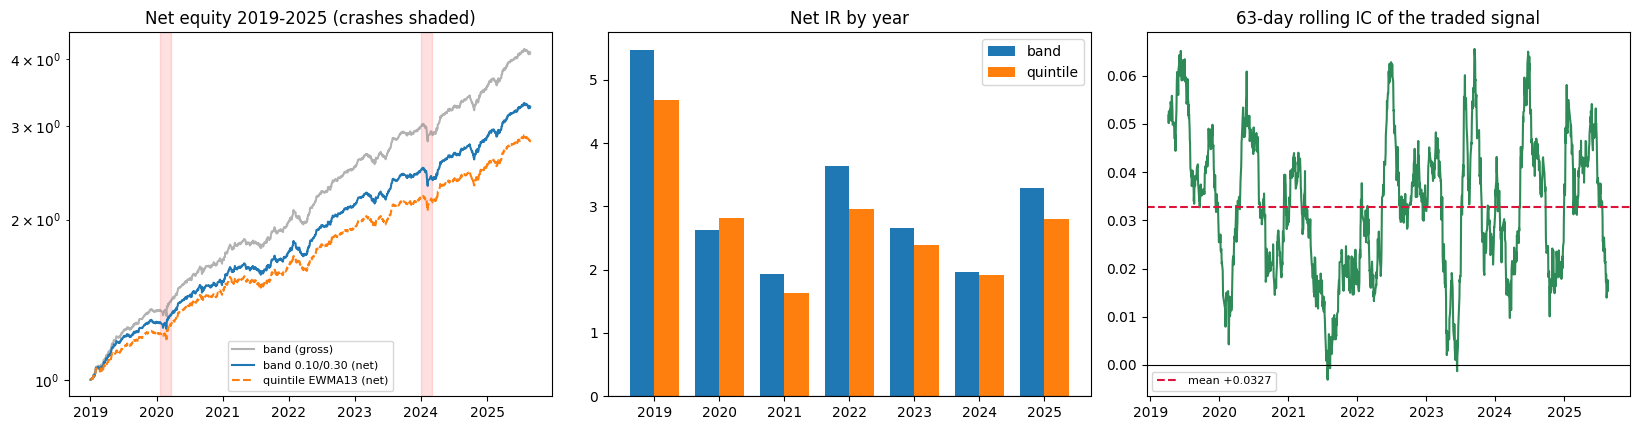

worst 5 days of the band book (net):
trade_date
2024-02-05   -0.0230
2024-10-08   -0.0166
2020-09-14   -0.0157
2024-02-02   -0.0134
2021-07-29   -0.0127


In [31]:
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4))

nav_b = (1 + book_band_s["net"].fillna(0)).cumprod()
nav_q = (1 + book_quin_s["net"].fillna(0)).cumprod()
nav_g = (1 + book_band_s["ls"].fillna(0)).cumprod()
ax[0].plot(nav_g.index, nav_g.values, color="grey", alpha=0.6, label="band (gross)")
ax[0].plot(nav_b.index, nav_b.values, label="band 0.10/0.30 (net)")
ax[0].plot(nav_q.index, nav_q.values, ls="--", label="quintile EWMA13 (net)")
for a, b in [("2020-01-20", "2020-03-23"), ("2024-01-01", "2024-02-29")]:
    ax[0].axvspan(pd.to_datetime(a), pd.to_datetime(b), color="red", alpha=0.12)
ax[0].set_yscale("log"); ax[0].set_title("Net equity 2019-2025 (crashes shaded)")
ax[0].legend(fontsize=8)

yr_b = book_band_s["net"].groupby(book_band_s["net"].index.year)
yr_q = book_quin_s["net"].groupby(book_quin_s["net"].index.year)
ir = lambda s: np.sqrt(NDAYS_E) * s.mean() / s.std() if s.std() > 0 else np.nan
yrs = sorted(yr_b.groups)
w = 0.38
ax[1].bar([y - w/2 for y in yrs], [ir(yr_b.get_group(y)) for y in yrs], w, label="band")
ax[1].bar([y + w/2 for y in yrs], [ir(yr_q.get_group(y)) for y in yrs], w, label="quintile")
ax[1].axhline(0, color="k", lw=0.8); ax[1].set_title("Net IR by year"); ax[1].legend()

roll_ic = ic_s.rolling(63).mean()
ax[2].plot(roll_ic.index, roll_ic.values, color="seagreen")
ax[2].axhline(0, color="k", lw=0.8); ax[2].axhline(ic_s.mean(), color="crimson", ls="--",
              label=f"mean {ic_s.mean():+.4f}")
ax[2].set_title("63-day rolling IC of the traded signal"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("worst 5 days of the band book (net):")
print(book_band_s["net"].nsmallest(5).round(4).to_string())

## F2. Verdict — it survives

**Full 2019-2025 walk-forward: net IR 2.89, +18.0%/yr net, max drawdown 7.5%** — across nearly
seven years and 26 quarterly retrains, with the first model trained only on 2017-18 data.

| Regime | Band net IR | Net ret (ann.) | Daily IC |
|---|---|---|---|
| 2019 (bull) | **5.48** | +25.4% | 0.043 |
| **2020 COVID crash** | **+2.19** | +21.9% | 0.034 |
| 2020 recovery | 3.10 | +18.8% | 0.033 |
| 2021 style rotation | 1.93 | +12.8% | 0.021 |
| 2022 (bear) | 3.64 | +21.1% | 0.035 |
| 2023 | 2.65 | +14.7% | 0.034 |
| **2024 microcap crash** | **−1.81** | −20.2% (ann.) | −0.004 |
| 2025 YTD | 3.29 | +19.9% | 0.031 |
| **FULL 2019-2025** | **2.89** | **+18.0%** | 0.033 |

Five observations:

1. **Every regime is profitable except one.** The market-neutral book sailed *through* the
   COVID crash (+2.19 IR during the panic itself) and the 2022 bear (3.64). Its weakest full
   year, the 2021 style rotation, still earned IR 1.9. This is what cross-sectional neutrality
   is supposed to buy, and it did.

2. **The one wound is the Jan-Feb 2024 microcap crash** — the event that wrecked much of the
   China quant industry. The book lost ≈3% over those weeks (its 7-year max drawdown of 7.5%
   sits exactly there), and the signal's IC briefly went negative: when *everyone* deleverages
   the same cross-sectional factors, the alpha itself inverts. Notably the slower quintile
   baseline lost *less* (−0.62 IR vs −1.81): hysteresis holds positions longer, so the band
   book absorbed more of the violent reversal. Crowding risk, not model risk, is this
   strategy's real tail.

3. **Worst days are all recognisable market events** — 2024-02-05 (microcap crash trough,
   −2.3%), 2024-10-08 (post-stimulus whipsaw), 2021-07-29 (policy-crackdown week). No silent
   single-day blowups beyond −2.5% in seven years.

4. **Gentle, survivable alpha decay.** IC drifts from 0.043 (2019) to ≈0.031-0.033 (2023-25) —
   these public alpha101/191 factors are slowly being arbitraged, but two-thirds of the edge
   remains. And since IC was *highest* before the construction-tuning era (2022-23), the
   recipe is clearly not an artifact of the period it was tuned on.

5. **The construction choice generalises.** The band book beats the quintile baseline over the
   full seven years (2.89 vs 2.58) and in most regimes — its only relative losses are the
   sharpest reversals, which is the price of hysteresis.

**Production implications:** the recipe stands, but the 2024 episode argues for a **crowding
kill-switch** (e.g. de-lever when trailing 10-day IC turns sharply negative) and for the
**sector/size neutralisation** test — if part of the edge is a persistent small-cap tilt, that
is exactly what got punished in Jan-2024.
